In [1]:
# Load libraries and data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Set style for better-looking plots
plt.rcParams['figure.figsize'] = (12, 8)

# Load the merged data
data = pd.read_csv('../data/processed/llm_as_judge_results_full.csv')
raw_data = pd.read_csv('../data/raw/item_level_data.csv') # ground truth
valid_pids = pd.read_csv('../data/raw/attention_check_failed.csv')

# Merge on BOTH participant_id and headline to avoid row multiplication
data = data.merge(
    raw_data[['participant_id', 'headline', 'ground_truth_with_AI', "before_AI_Real_Fake", "with_AI_Real_Fake", "after_AI_Real_Fake", "after_AI_ground_truth"]], 
    on=['participant_id', 'headline'], 
    how='left'
).rename(columns={'ground_truth_with_AI': 'ground_truth', 'before_AI_Real_Fake': 'initial_rating', 'with_AI_Real_Fake': 'final_rating', 'after_AI_Real_Fake': 'unassisted_rating', 'after_AI_ground_truth': 'unassisted_ground_truth'})

data['ground_truth'] = data['ground_truth'].str.capitalize() #first letter uppercase
data['initial_rating'] = data['initial_rating'].str.capitalize() #first letter uppercase
data['congruent_belief'] = data.apply(lambda row: 'Congruent' if (row['ground_truth'] == row['initial_rating']) else 'Incongruent', axis=1)
data['accuracy_before'] = data["initial_rating"].str.capitalize() == data["ground_truth"].str.capitalize()
data['accuracy_with'] = data["final_rating"].str.capitalize() == data["ground_truth"].str.capitalize()
data['accuracy_unassisted'] = data["unassisted_rating"].str.capitalize() == data["unassisted_ground_truth"].str.capitalize()

# strategies
data['gave_away_answer_beginning'] = data['gave_away_ground_truth'] == 0
data['gave_away_answer_end'] = data['gave_away_ground_truth'] == 1
data['gave_away_answer_never'] = data['gave_away_ground_truth'] == 2

# Only include participants also in processed data
condition1_only = raw_data[raw_data.condition == "Persuasive"]['participant_id'].unique()
data = data[data['participant_id'].isin(valid_pids['participant_id']) & data['participant_id'].isin(condition1_only)]


# Show
data.to_csv('../data/processed/llm_as_judge_results_filtered_pids.csv', index=False)
#data.head(3)
data

,just_the_facts,gave_away_ground_truth,conversation_id,participant_id,condition,imageid,headline,phase,week,asked_broad_questions,...,final_rating,unassisted_rating,unassisted_ground_truth,congruent_belief,accuracy_before,accuracy_with,accuracy_unassisted,gave_away_answer_beginning,gave_away_answer_end,gave_away_answer_never
40,1,0,5e35373e1ddb124e6c306747_0,5e35373e1ddb124e6c306747,1,0,"Senator Christopher J. Dodd, with his wife and...",1,0,0,...,FAKE,Fake,fake,Incongruent,False,True,True,True,False,False
41,0,0,5e35373e1ddb124e6c306747_1,5e35373e1ddb124e6c306747,1,1,An immigrant viciously attacks medical personn...,1,0,1,...,FAKE,Fake,fake,Congruent,True,True,True,True,False,False
42,1,0,5e35373e1ddb124e6c306747_6,5e35373e1ddb124e6c306747,1,6,Pictures of King Abdullah II of Jordan at a fr...,1,0,0,...,REAL,Real,real,Incongruent,False,True,True,True,False,False
43,1,0,5e35373e1ddb124e6c306747_12,5e35373e1ddb124e6c306747,1,12,People kept away from each other to avoid spre...,1,0,1,...,REAL,Real,real,Congruent,True,True,True,True,False,False
44,0,2,5e916cb9e502b1498e8fc059_0,5e916cb9e502b1498e8fc059,1,0,"Senator Christopher J. Dodd, with his wife and...",1,0,1,...,FAKE,Fake,fake,Congruent,True,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,1,0,67659224c577c7e97b074f43_3,67659224c577c7e97b074f43,Persuasive,3,"President Mahmoud Ahmadinejad, center, incites...",3,4,1,...,FAKE,Real,Real,Congruent,True,True,True,True,False,False
736,1,0,5e35373e1ddb124e6c306747_2,5e35373e1ddb124e6c306747,Persuasive,2,Bangkok residents wave flags in celebration of...,3,4,1,...,FAKE,Real,Real,Congruent,True,True,True,True,False,False
737,1,0,5e35373e1ddb124e6c306747_3,5e35373e1ddb124e6c306747,Persuasive,3,"President Mahmoud Ahmadinejad, center, incites...",3,4,1,...,FAKE,Real,Real,Congruent,True,True,True,True,False,False
738,1,0,5e35373e1ddb124e6c306747_7,5e35373e1ddb124e6c306747,Persuasive,7,Protesters using slingshots during a protest i...,3,4,1,...,REAL,Fake,Fake,Congruent,True,True,True,True,False,False


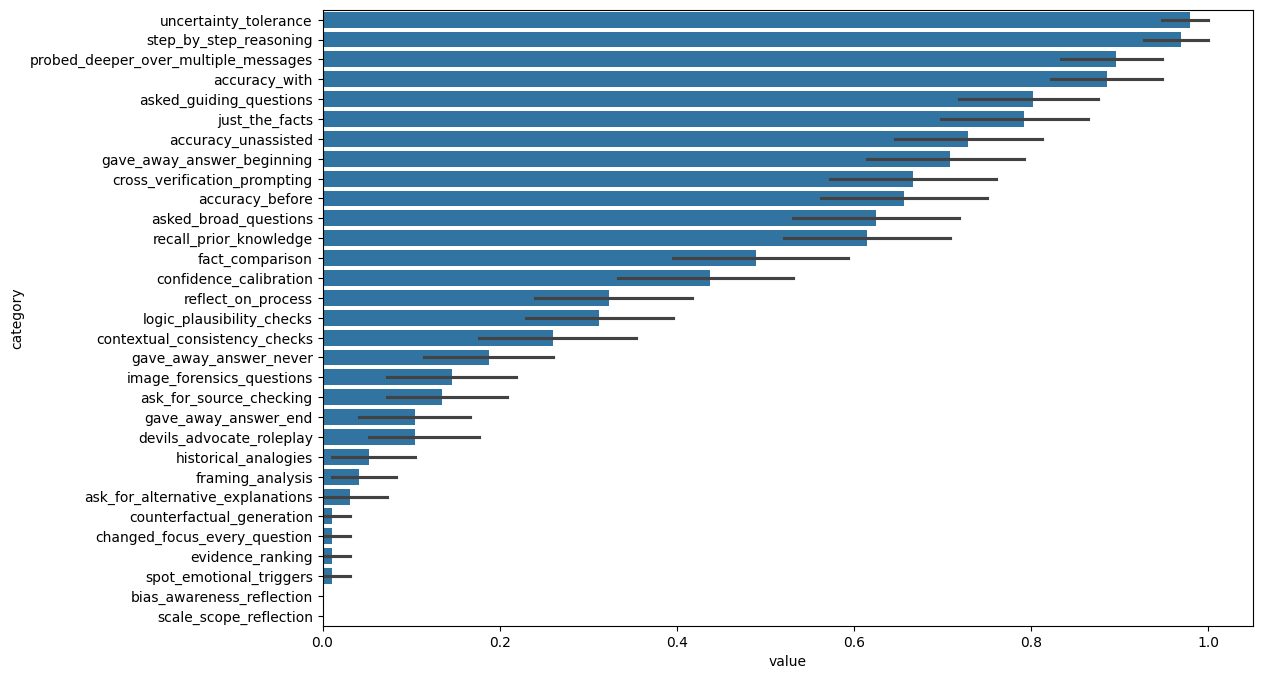

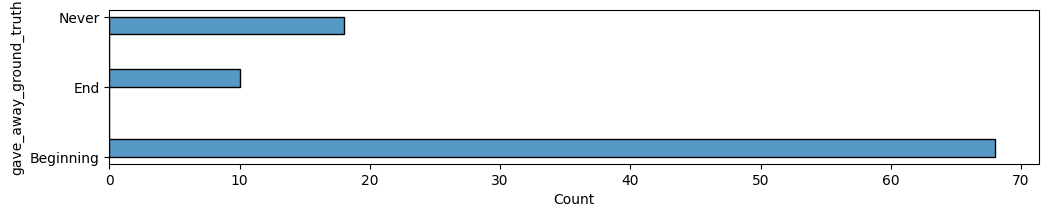

In [5]:
# plot vertical bar chart of frequency of each category in all columns except 'participant_id' and 'headline' and 'Week'
# the ones not in the following array (do not use '.difference')
category_columns = data.columns.difference(['participant_id', 'headline', 'Week', 'imageid', 'phase', 'condition', 'gave_away_ground_truth', 'week'])

# Melt the dataframe to include all category columns on the y-axis with frequency on the x-axis
plot_data = data.melt(value_vars=category_columns, var_name='category', value_name='value')
plot_data['value'] = pd.to_numeric(plot_data['value'], errors='coerce')
plot_data = plot_data.dropna(subset=['value'])

# Order categories by mean value
category_order = plot_data.groupby('category')['value'].mean().sort_values(ascending=False).index
plot_data['category'] = pd.Categorical(plot_data['category'], categories=category_order, ordered=True)

# Plot vertical frequency plot with seaborn
fig = plt.figure(figsize=(12, 8))
fig = sns.barplot(data=plot_data, y='category', x='value')
plt.show()

# Plot when gave away truth
data['gave_away_ground_truth'] = data["gave_away_ground_truth"].astype(int)
fig = plt.figure(figsize=(12, 2))
fig = sns.histplot(data=data, y='gave_away_ground_truth')
plt.yticks(ticks=[0, 1, 2], labels=['Beginning', 'End', 'Never'])
plt.show()


['just_the_facts', 'asked_broad_questions', 'asked_guiding_questions', 'probed_deeper_over_multiple_messages', 'changed_focus_every_question', 'gave_away_answer_beginning', 'gave_away_answer_end', 'gave_away_answer_never']
changed_focus_every_question 0.010416666666666666
gave_away_answer_end 0.10416666666666667
gave_away_answer_never 0.1875
asked_broad_questions 0.625
gave_away_answer_beginning 0.7083333333333334
just_the_facts 0.7916666666666666
asked_guiding_questions 0.8020833333333334
probed_deeper_over_multiple_messages 0.8958333333333334
ask_for_source_checking 0.13541666666666666
image_forensics_questions 0.14583333333333334
contextual_consistency_checks 0.2604166666666667
cross_verification_prompting 0.6666666666666666
scale_scope_reflection 0.0
counterfactual_generation 0.010416666666666666
ask_for_alternative_explanations 0.03125
logic_plausibility_checks 0.3125
bias_awareness_reflection 0.0
spot_emotional_triggers 0.010416666666666666
framing_analysis 0.041666666666666664
h

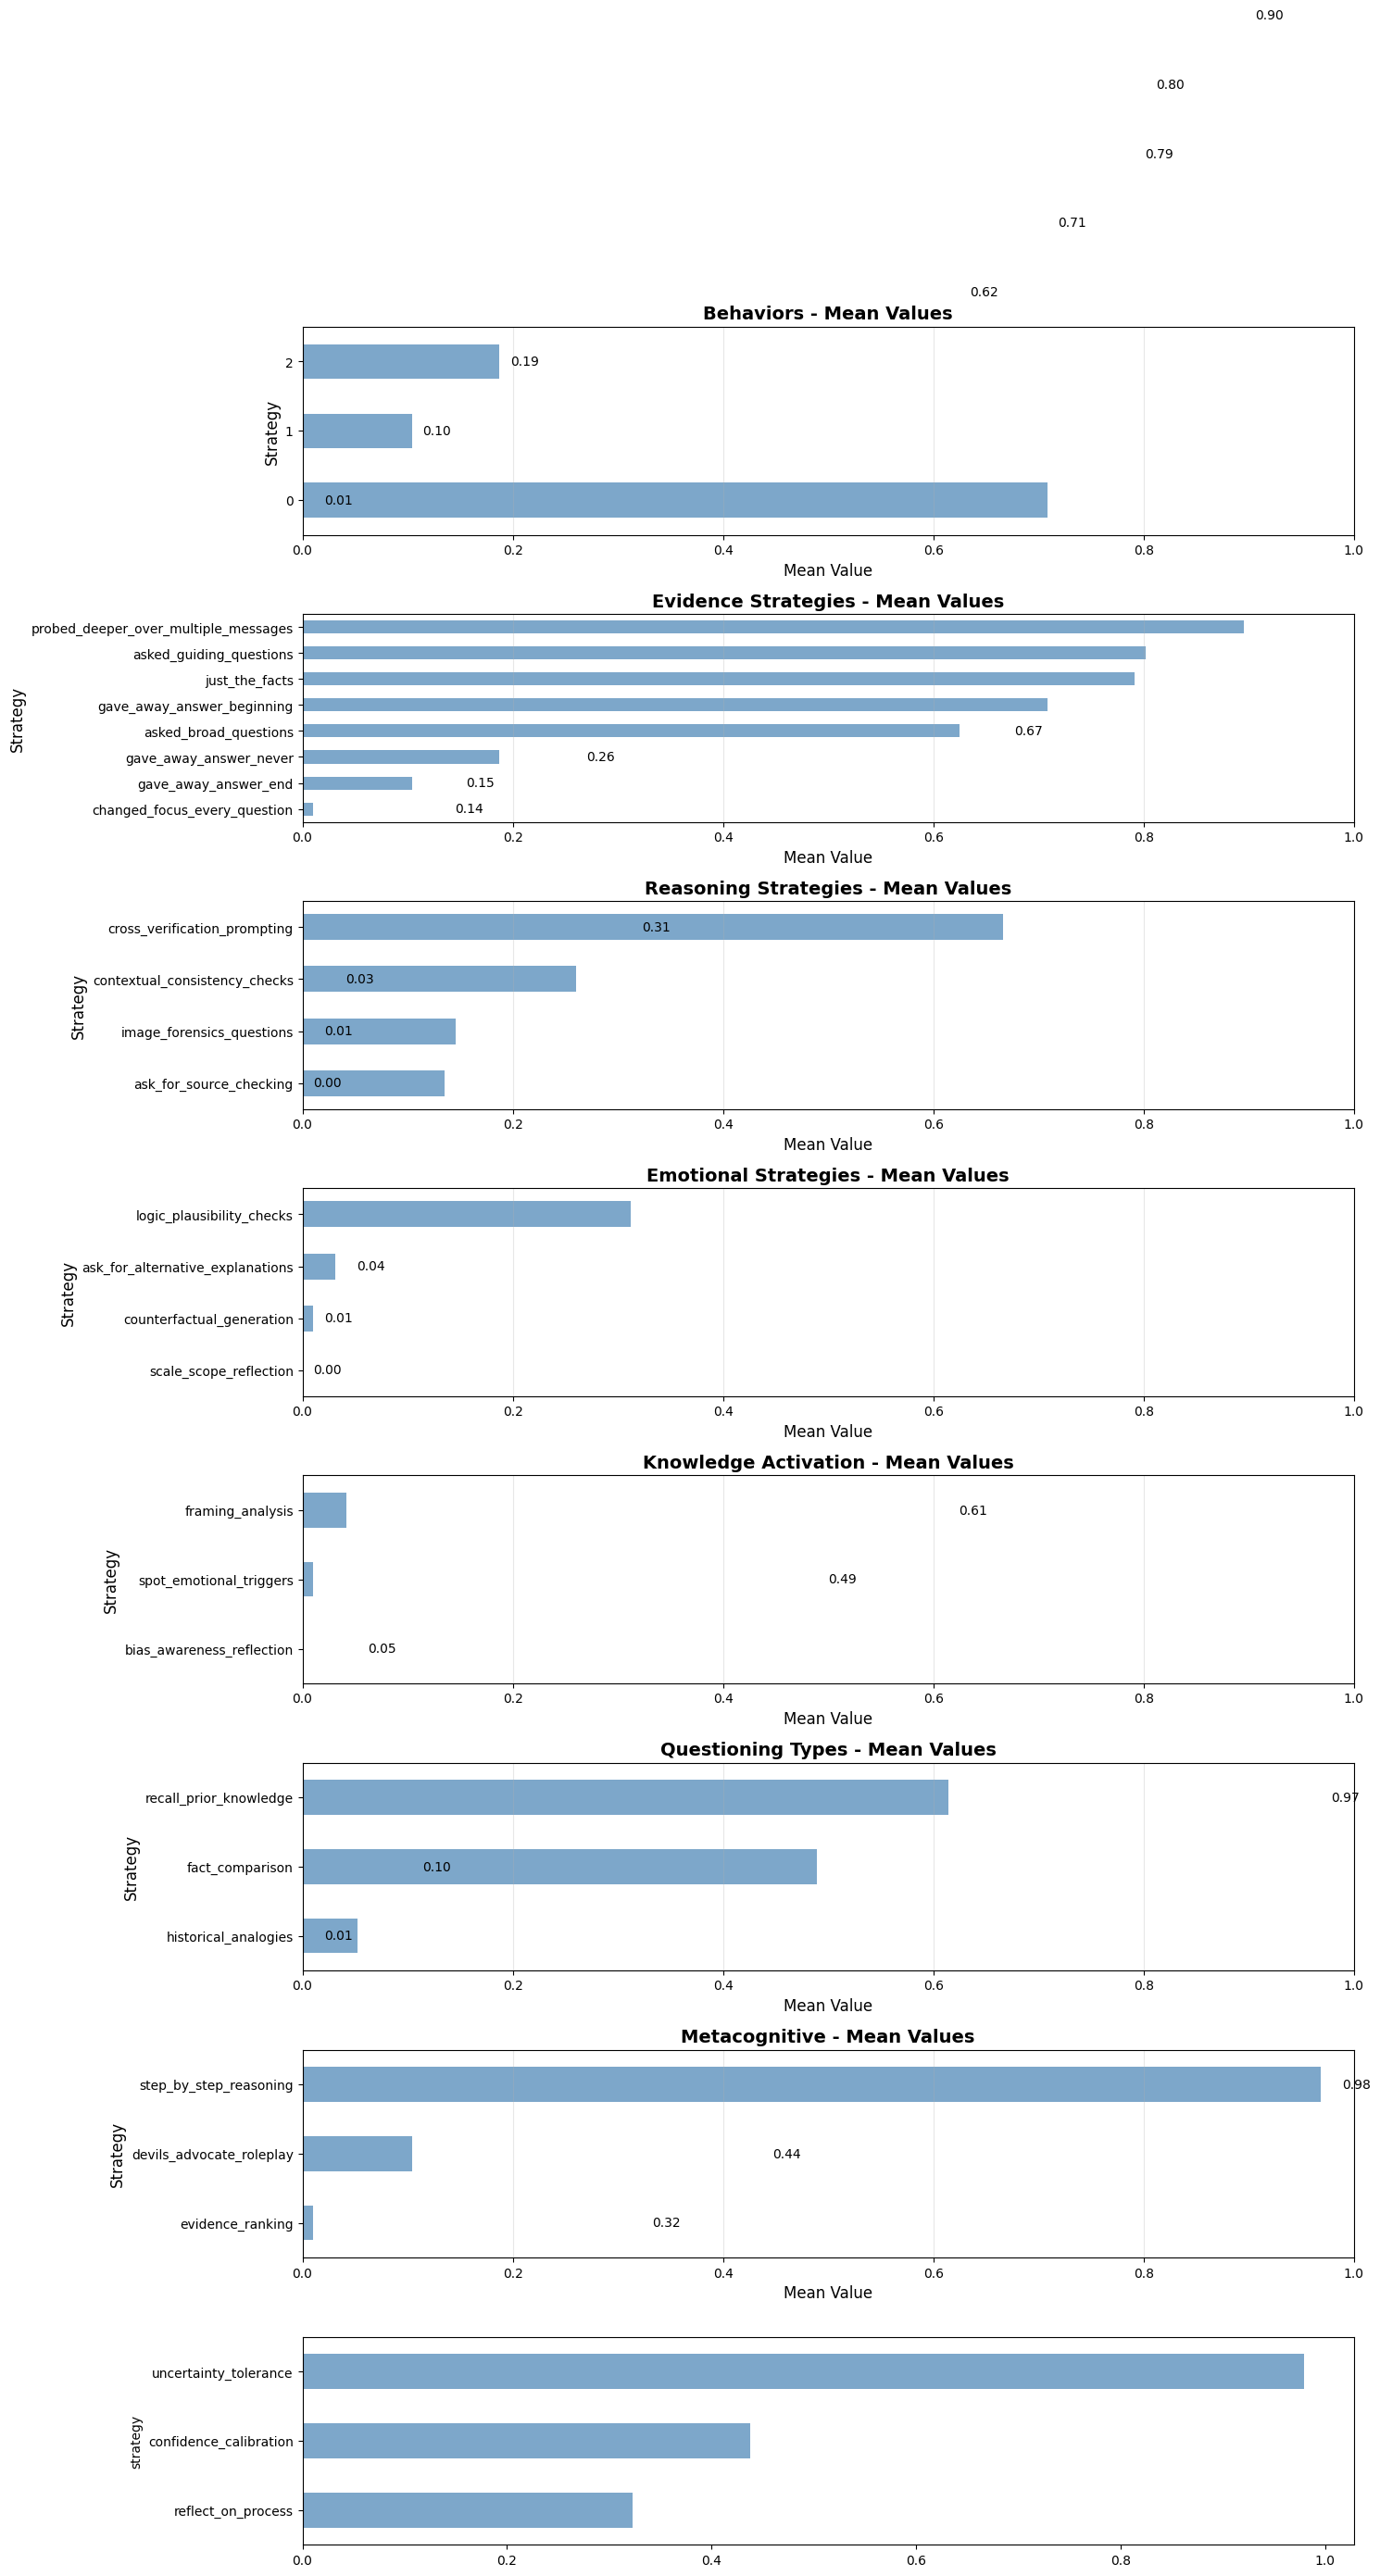

In [6]:
# Import classifier categories from classifier_prompts.py
import sys
sys.path.append('classifiers_llm')
from classifier_prompts import behaviors, evidence_strategies, reasoning_strategies, emotional_strategies, knowledge_activation, questioning_types, metacognitive

# Create a mapping of all classifier categories
all_categories = {
    'Behaviors': {k: v for k, v in behaviors.items() if k != "gave_away_ground_truth"},
    'Evidence Strategies': evidence_strategies,
    'Reasoning Strategies': reasoning_strategies,
    'Emotional Strategies': emotional_strategies,
    'Knowledge Activation': knowledge_activation,
    'Questioning Types': questioning_types,
    'Metacognitive': metacognitive
}

# Add the extra categories for gave away ground truth beginning, end, never within behaviors
all_categories['Behaviors']['gave_away_answer_beginning'] = "Gave Away Answer Beginning"
all_categories['Behaviors']['gave_away_answer_end'] = "Gave Away Answer End"
all_categories['Behaviors']['gave_away_answer_never'] = "Gave Away Answer Never"

print([item for item in all_categories["Behaviors"].keys()])

# Create subplots for each category group
fig, axes = plt.subplots(len(all_categories)+1, 1, figsize=(15, 4 * len(all_categories)))
if len(all_categories) == 1:
    axes = [axes]

# In the first row we will just plot the "gave_ground_truth_away" with the values 0,1,2
# 0 = never, 1 = beginning, 2 = end and plotted as y-tick labels
prop_data = data[data.ground_truth == "Fake"].copy() 
prop_data_gave = data[data.gave_away_ground_truth!="ERROR"]["gave_away_ground_truth"].value_counts(normalize=True).sort_index()
# change these correctly to fit the values [0='Beginning', 1='End', 2='Never']

prop_data_gave.plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('Gave Away Ground Truth - Proportions', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Proportion', fontsize=12)
axes[0].set_ylabel('Gave Away Ground Truth', fontsize=12)


for idx, (category_name, category_dict) in enumerate(all_categories.items()):
    # Get the column names that exist in our data
    existing_columns = [col for col in category_dict.keys() if col in data.columns]
    
    if existing_columns:
        # Create subset of data for this category
        category_data = data[existing_columns]

        # Melt the data for plotting
        melted_data = category_data.melt(var_name='strategy', value_name='value')
        melted_data['value'] = pd.to_numeric(melted_data['value'], errors='coerce')
        melted_data = melted_data.dropna(subset=['value'])
        
        # Calculate proportions for each strategy
        prop_data = melted_data.groupby('strategy')['value'].mean().sort_values(ascending=True)
        
        # Create horizontal bar plot with ground truth as hue
        prop_data.plot(kind='barh', ax=axes[idx+1], color='steelblue', alpha=0.7)
        axes[idx].set_title(f'{category_name} - Mean Values', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Mean Value', fontsize=12)
        axes[idx].set_ylabel('Strategy', fontsize=12)
        axes[idx].set_xlim(0, 1)
        axes[idx].grid(axis='x', alpha=0.3)
        
        # Add value labels on bars
        for i, v in prop_data.items():
            print(i, v)

        for i, v in enumerate(prop_data.values):
            axes[idx].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=10)
    # else:
    #     axes[idx].text(0.5, 0.5, f'No data found for {category_name}', 
    #                   ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
    #     axes[idx].set_title(f'{category_name} - No Data Available', fontsize=14)

plt.tight_layout()
plt.show()

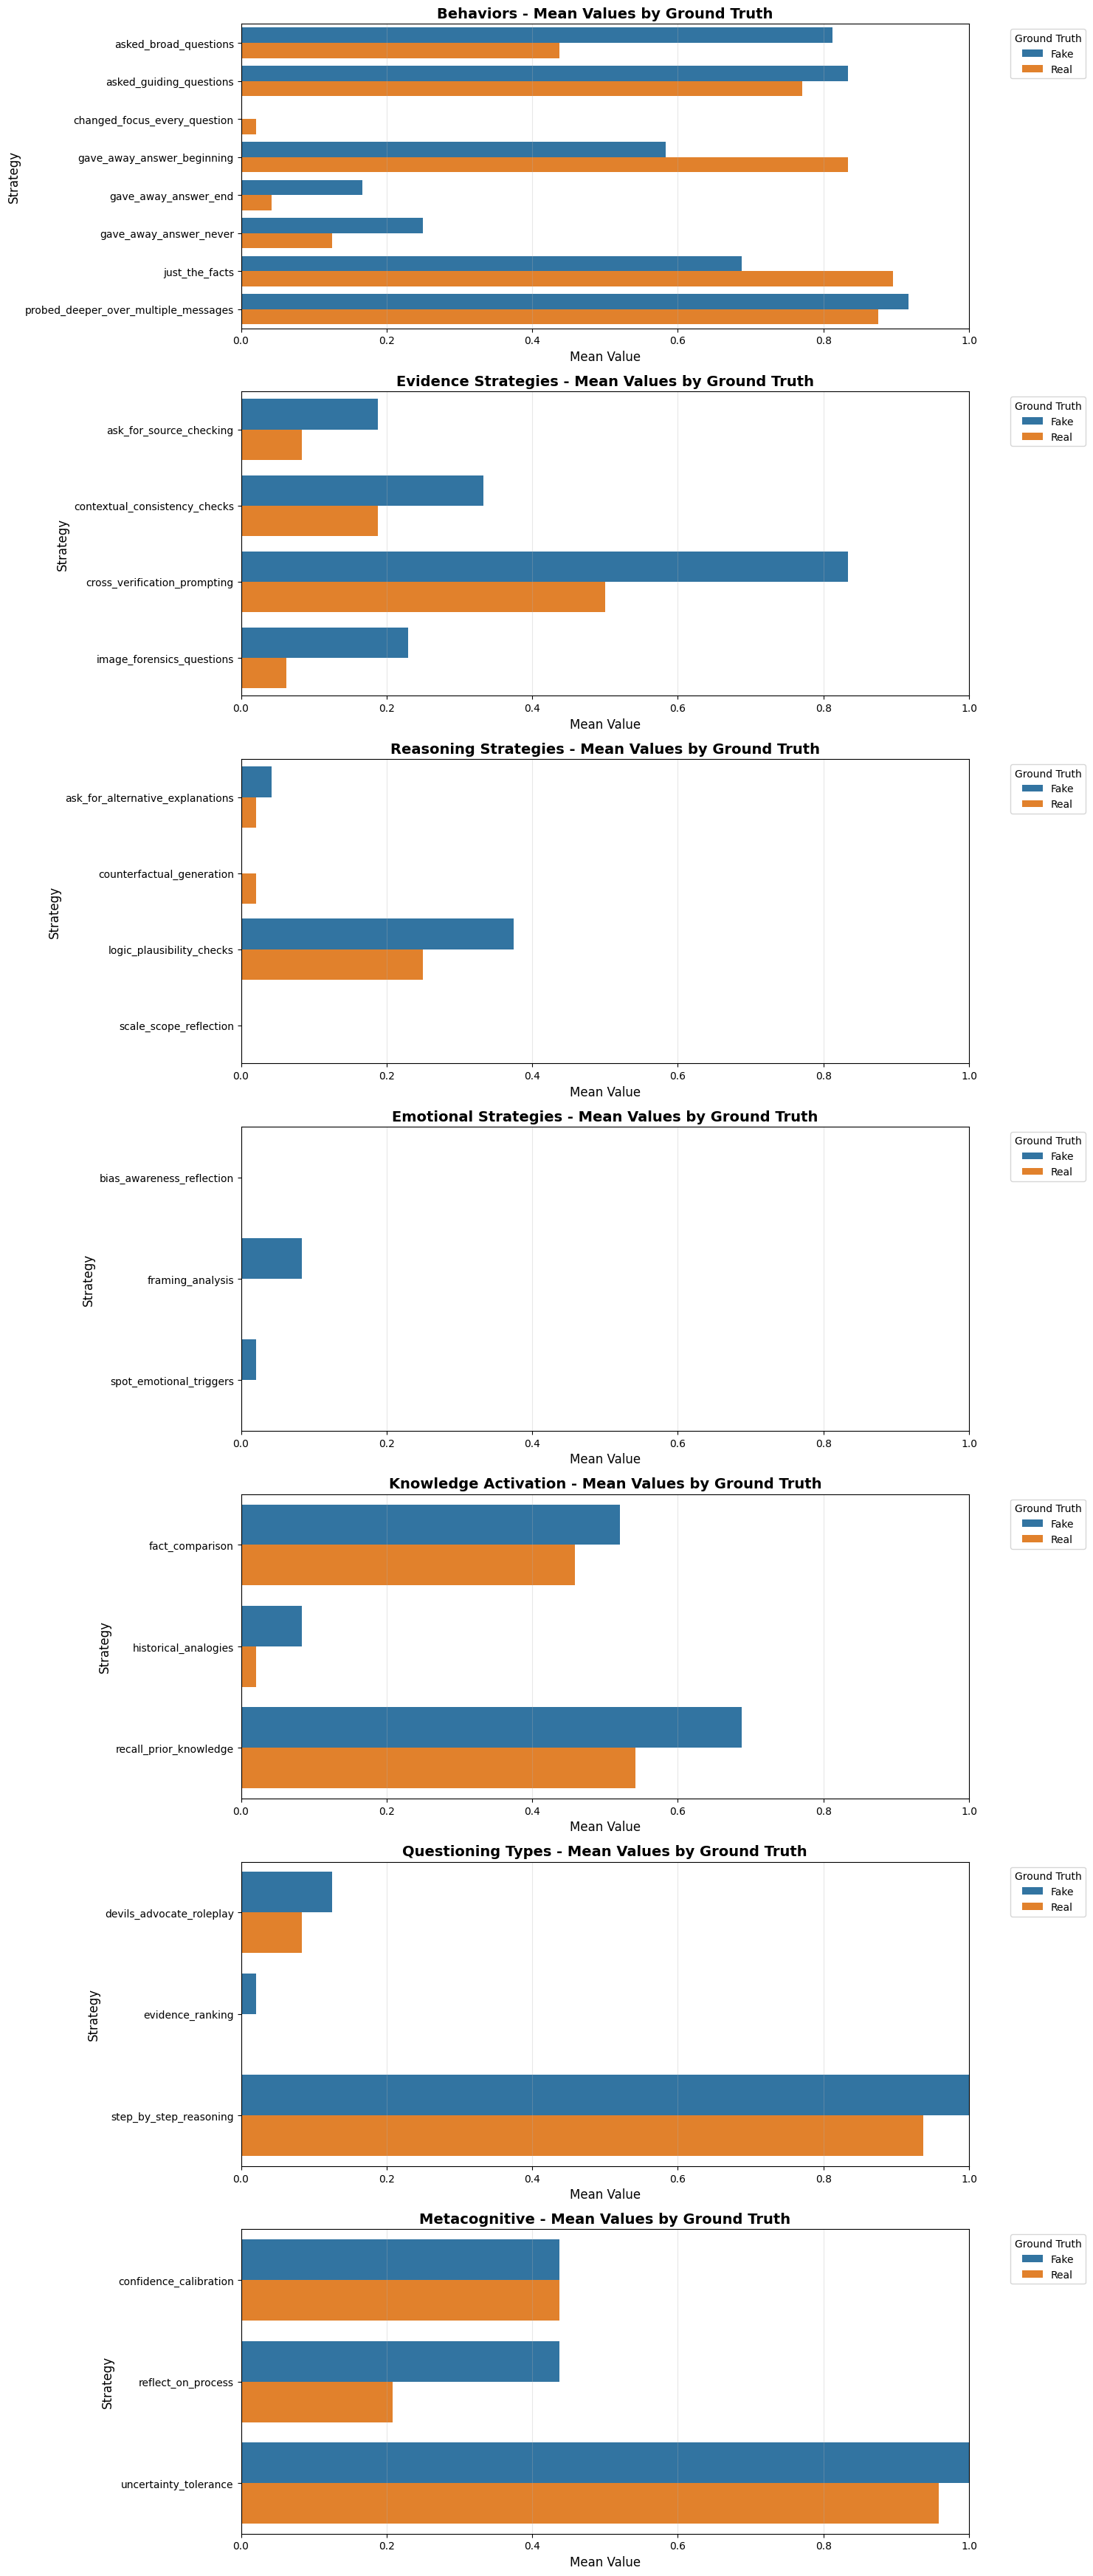

In [7]:
# Fixed visualization with proper ground truth breakdown
# Create subplots for each category group with ground truth comparison
fig, axes = plt.subplots(len(all_categories), 1, figsize=(15, 5 * len(all_categories)))
if len(all_categories) == 1:
    axes = [axes]

for idx, (category_name, category_dict) in enumerate(all_categories.items()):
    # Get the column names that exist in our data
    existing_columns = [col for col in category_dict.keys() if col in data.columns]
    
    if existing_columns:
        # Create subset of data for this category, including ground truth
        category_data = data[existing_columns + ['ground_truth']].copy()
        
        # Melt the data for plotting
        melted_data = category_data.melt(
            id_vars=['ground_truth'], 
            value_vars=existing_columns, 
            var_name='strategy', 
            value_name='value'
        )
        melted_data['value'] = pd.to_numeric(melted_data['value'], errors='coerce')
        melted_data = melted_data.dropna(subset=['value'])
        
        # Calculate mean values grouped by strategy and ground truth
        grouped_data = melted_data.groupby(['strategy', 'ground_truth'])['value'].mean().reset_index()
        
        # Create horizontal bar plot with ground truth as hue
        sns.barplot(
            data=grouped_data, 
            x='value', 
            y='strategy', 
            hue='ground_truth', 
            ax=axes[idx], 
            palette=['#1f77b4', '#ff7f0e'],  # Blue for False, Orange for True
            orient='h'
        )
        
        axes[idx].set_title(f'{category_name} - Mean Values by Ground Truth', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Mean Value', fontsize=12)
        axes[idx].set_ylabel('Strategy', fontsize=12)
        axes[idx].set_xlim(0, 1)
        axes[idx].grid(axis='x', alpha=0.3)
        axes[idx].legend(title='Ground Truth', bbox_to_anchor=(1.05, 1), loc='upper left')
        
    else:
        axes[idx].text(0.5, 0.5, f'No data found for {category_name}', 
                      ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
        axes[idx].set_title(f'{category_name} - No Data Available', fontsize=14)

plt.tight_layout()
plt.show()

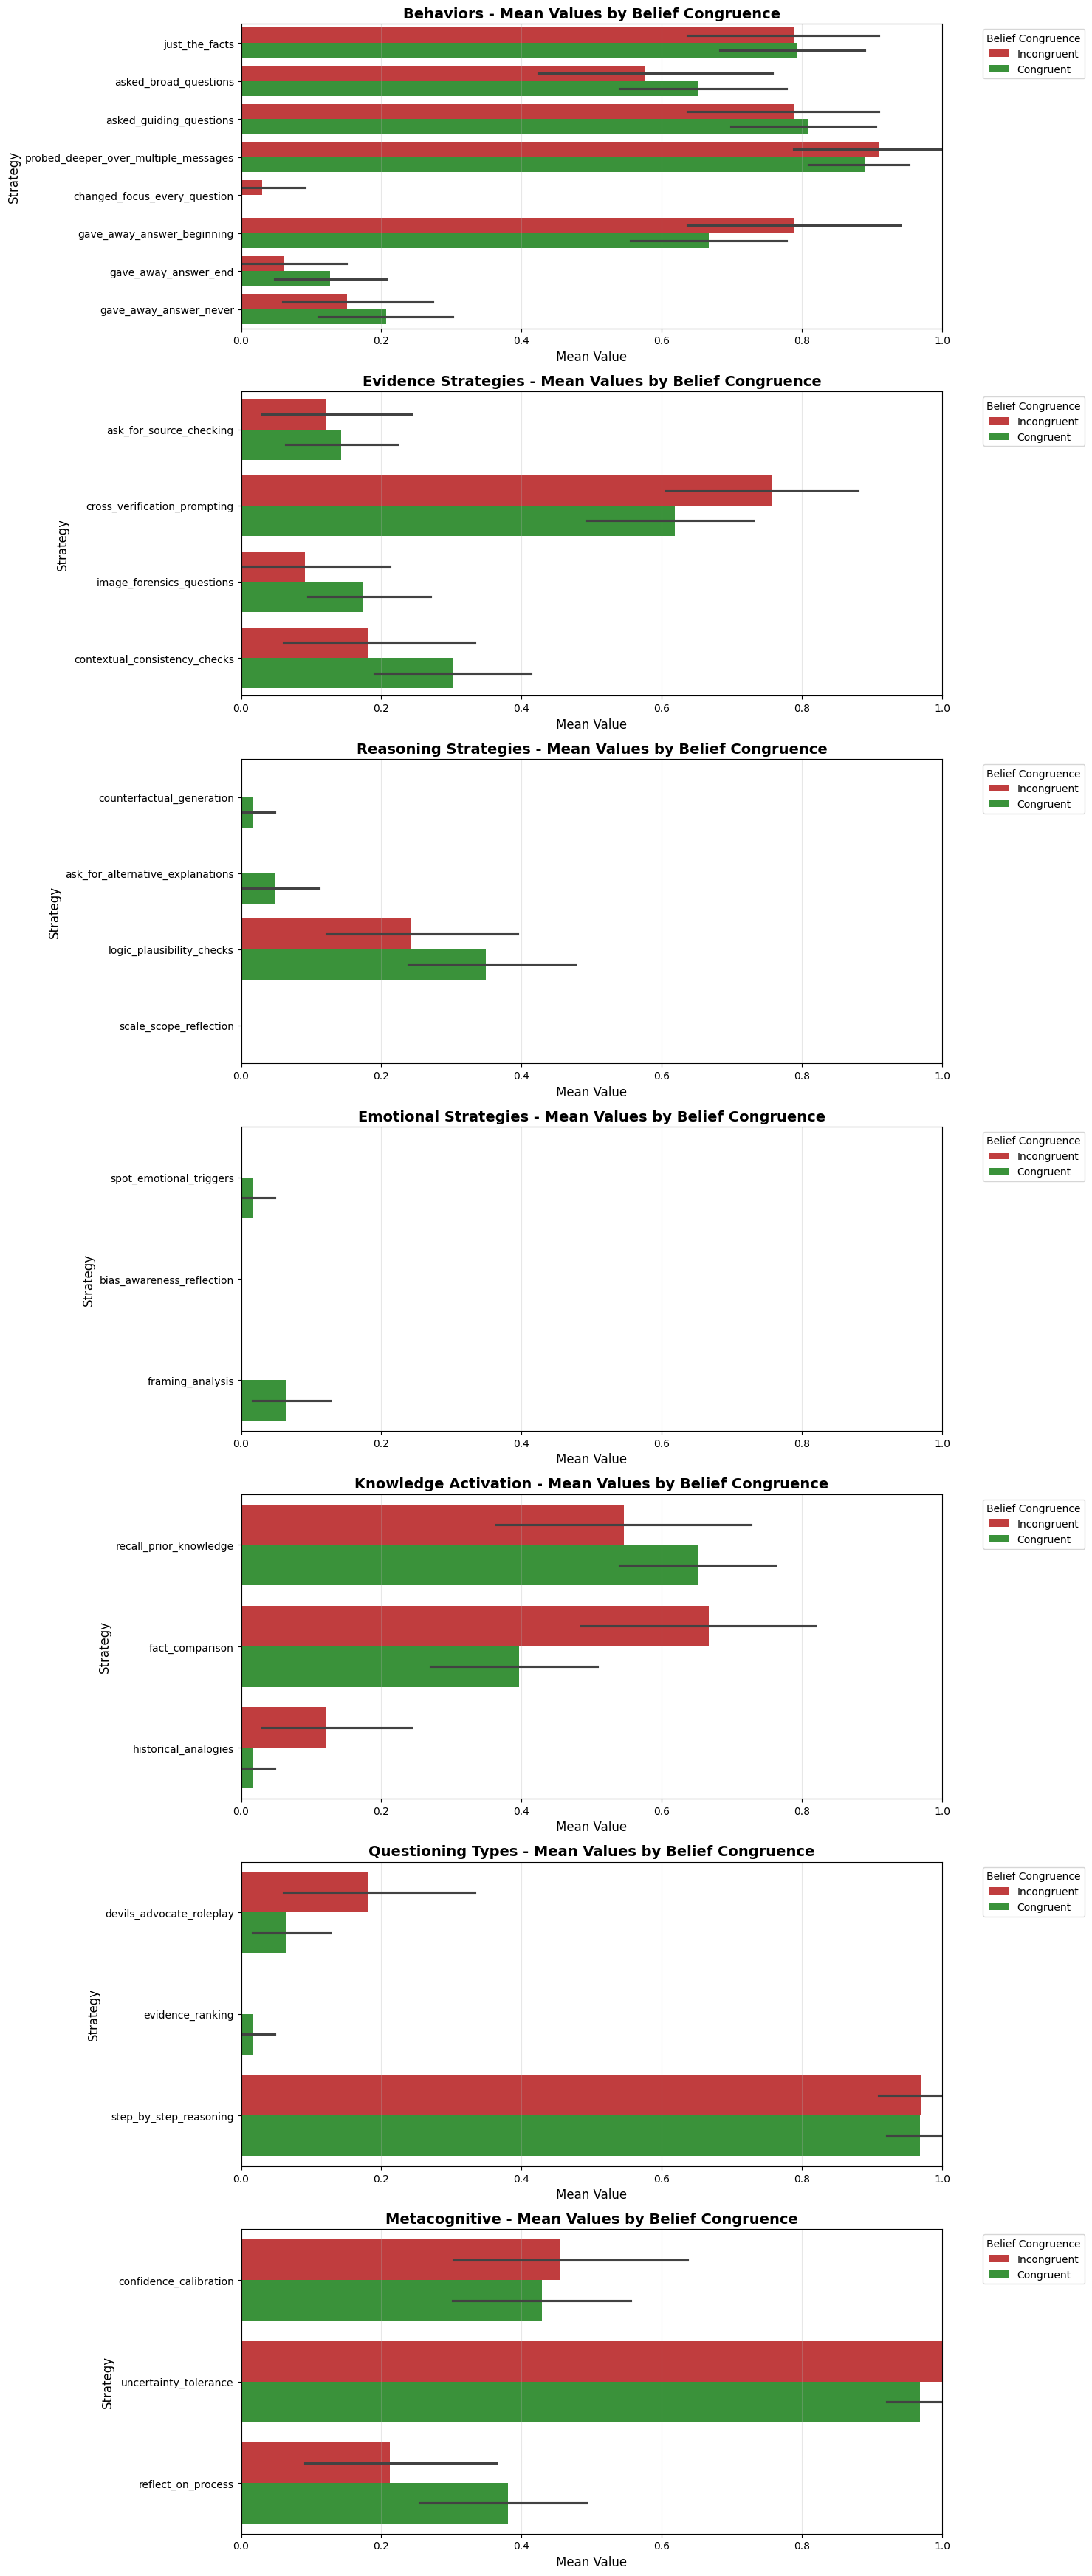

Distribution of belief congruence:
congruent_belief
Congruent      63
Incongruent    33
Name: count, dtype: int64

Percentages:
congruent_belief
Congruent      65.625
Incongruent    34.375
Name: proportion, dtype: float64


In [6]:
# Visualization with congruent vs incongruent belief breakdown
# Create subplots for each category group with congruent belief comparison
fig, axes = plt.subplots(len(all_categories), 1, figsize=(15, 5 * len(all_categories)))
if len(all_categories) == 1:
    axes = [axes]

for idx, (category_name, category_dict) in enumerate(all_categories.items()):
    # Get the column names that exist in our data
    existing_columns = [col for col in category_dict.keys() if col in data.columns]
    
    if existing_columns:
        # Create subset of data for this category, including congruent_belief
        category_data = data[existing_columns + ['congruent_belief']].copy()
        
        # Melt the data for plotting
        melted_data = category_data.melt(
            id_vars=['congruent_belief'], 
            value_vars=existing_columns, 
            var_name='strategy', 
            value_name='value'
        )
        melted_data['value'] = pd.to_numeric(melted_data['value'], errors='coerce')
        melted_data = melted_data.dropna(subset=['value'])
        
        # Calculate mean values grouped by strategy and congruent_belief
        #grouped_data = melted_data.groupby(['strategy', 'congruent_belief'])['value'].mean().reset_index()
        
        # Create horizontal bar plot with congruent_belief as hue
        sns.barplot(
            data=melted_data, 
            x='value', 
            y='strategy', 
            hue='congruent_belief', 
            ax=axes[idx], 
            palette=['#d62728', '#2ca02c'],  # Red for Incongruent, Green for Congruent
            orient='h'
        )
        
        axes[idx].set_title(f'{category_name} - Mean Values by Belief Congruence', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Mean Value', fontsize=12)
        axes[idx].set_ylabel('Strategy', fontsize=12)
        axes[idx].set_xlim(0, 1)
        axes[idx].grid(axis='x', alpha=0.3)
        axes[idx].legend(title='Belief Congruence', bbox_to_anchor=(1.05, 1), loc='upper left')
        
    else:
        axes[idx].text(0.5, 0.5, f'No data found for {category_name}', 
                      ha='center', va='center', transform=axes[idx].transAxes, fontsize=12)
        axes[idx].set_title(f'{category_name} - No Data Available', fontsize=14)

plt.tight_layout()
plt.show()

# Show distribution of congruent vs incongruent beliefs
print("Distribution of belief congruence:")
print(data['congruent_belief'].value_counts())
print(f"\nPercentages:")
print(data['congruent_belief'].value_counts(normalize=True) * 100)

/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


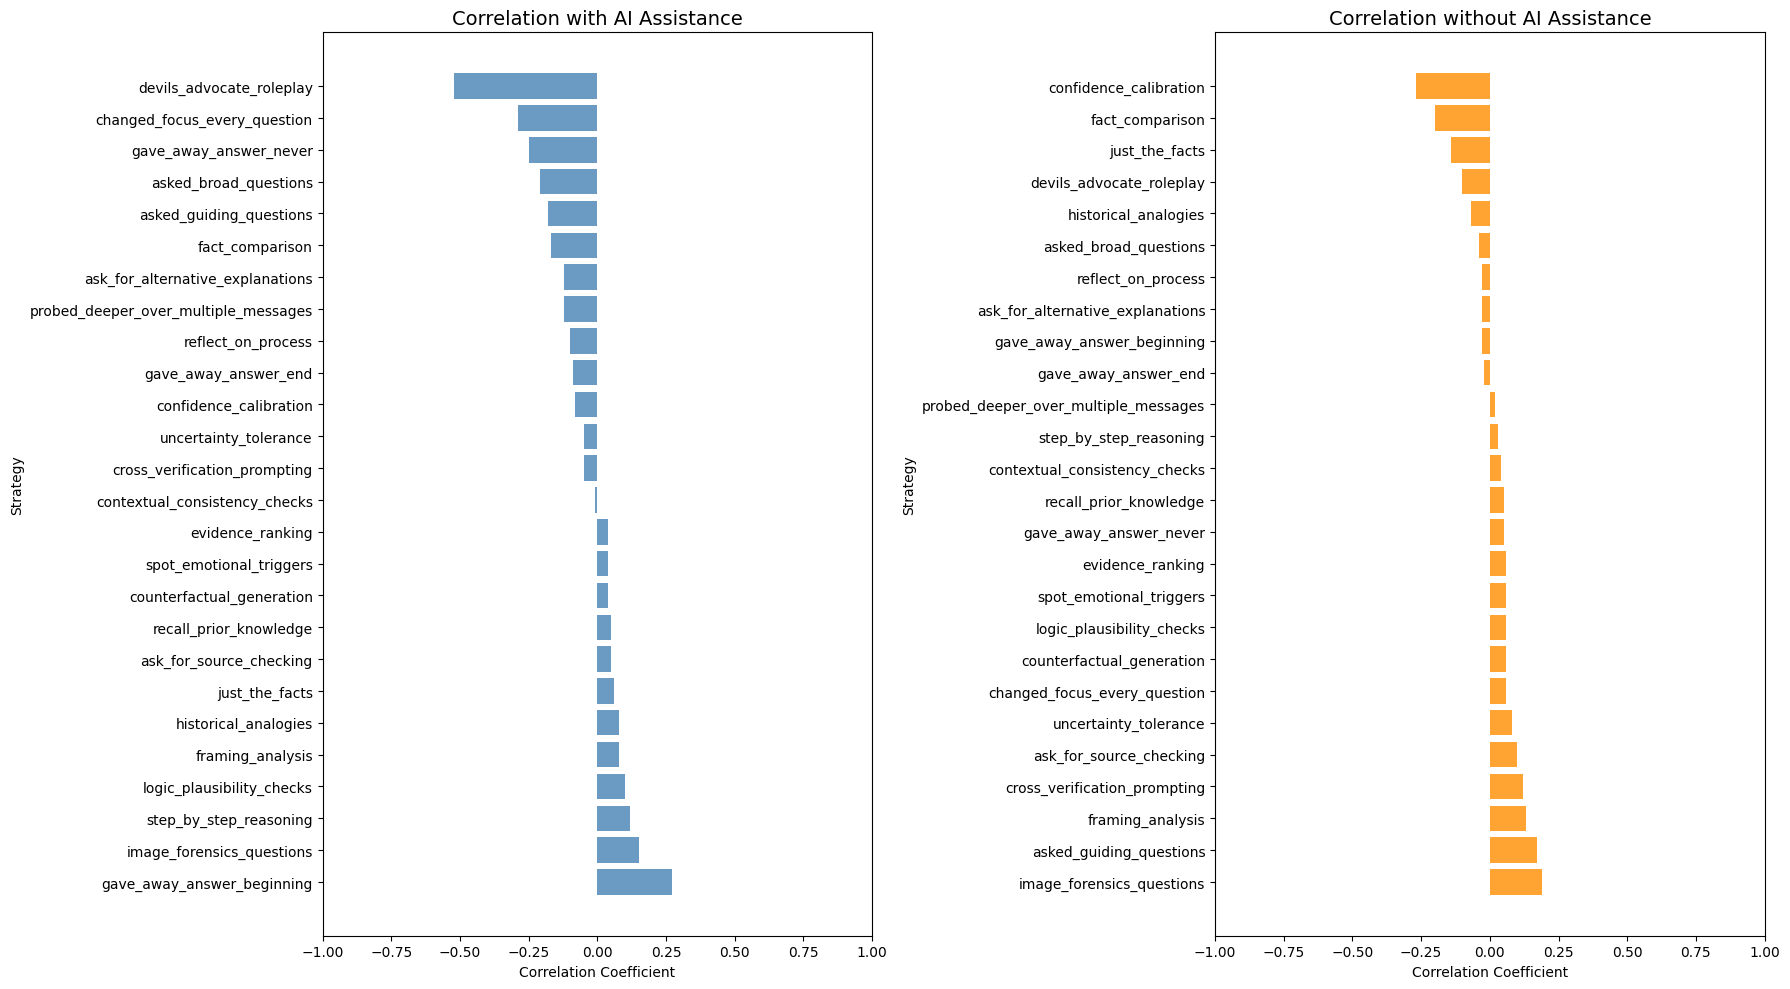

In [8]:
# correlation between accuracy and all strategies
# print the correlation coefficients between accuracy and all strategies
correlations_with = {}
correlations_unassisted = {}
for category_name, category_dict in all_categories.items():
    for strategy in category_dict.keys():
        if strategy in data.columns:

            corr = data[['accuracy_with', strategy]].dropna()
            corr = corr['accuracy_with'].corr(corr[strategy])
            correlations_with[strategy] = round(corr,2)
            corr_unassisted = data['accuracy_unassisted'].corr(data[strategy])
            correlations_unassisted[strategy] = round(corr_unassisted,2)

# sort and print correlations for each with and without assistance
correlations_with = dict(sorted(correlations_with.items(), key=lambda item: item[1], reverse=True))
correlations_unassisted = dict(sorted(correlations_unassisted.items(), key=lambda item: item[1], reverse=True))

# prep fig
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Remove strategies with NaN correlations for plotting
plot_corr_with = {k: v for k, v in correlations_with.items() if not np.isnan(v)}
plot_corr_unassisted = {k: v for k, v in correlations_unassisted.items() if not np.isnan(v)}


# Plot for "with AI assistance"
axes[0].barh(list(plot_corr_with.keys()), list(plot_corr_with.values()), color='steelblue', alpha=0.8)
axes[0].set_title("Correlation with AI Assistance", fontsize=14)
axes[0].set_xlabel("Correlation Coefficient")
axes[0].set_ylabel("Strategy")
axes[0].set_xlim(-1, 1)

# Plot for "without AI assistance"
axes[1].barh(list(plot_corr_unassisted.keys()), list(plot_corr_unassisted.values()), color='darkorange', alpha=0.8)
axes[1].set_title("Correlation without AI Assistance", fontsize=14)
axes[1].set_xlabel("Correlation Coefficient")
axes[1].set_ylabel("Strategy")
axes[1].set_xlim(-1, 1)

plt.tight_layout()
plt.show()

/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/valdemardanry/Documents/GitHub/news_veracity_and_conversational_ai/.venv/lib/python3.12/site-packages

Correlations with AI Assistance:
gave_away_answer_beginning: 0.25
image_forensics_questions: 0.23
recall_prior_knowledge: 0.23
framing_analysis: 0.12
historical_analogies: 0.12
logic_plausibility_checks: 0.08
spot_emotional_triggers: 0.06
evidence_ranking: 0.06
ask_for_source_checking: 0.05
contextual_consistency_checks: 0.04
reflect_on_process: 0.01
just_the_facts: -0.02
confidence_calibration: -0.11
probed_deeper_over_multiple_messages: -0.12
gave_away_answer_end: -0.13
gave_away_answer_never: -0.17
asked_guiding_questions: -0.18
cross_verification_prompting: -0.18
asked_broad_questions: -0.2
ask_for_alternative_explanations: -0.21
fact_comparison: -0.28
devils_advocate_roleplay: -0.56

Correlations without AI Assistance:
asked_guiding_questions: 0.29
probed_deeper_over_multiple_messages: 0.19
image_forensics_questions: 0.18
recall_prior_knowledge: 0.17
framing_analysis: 0.16
ask_for_source_checking: 0.13
logic_plausibility_checks: 0.12
gave_away_answer_never: 0.09
spot_emotional_tri

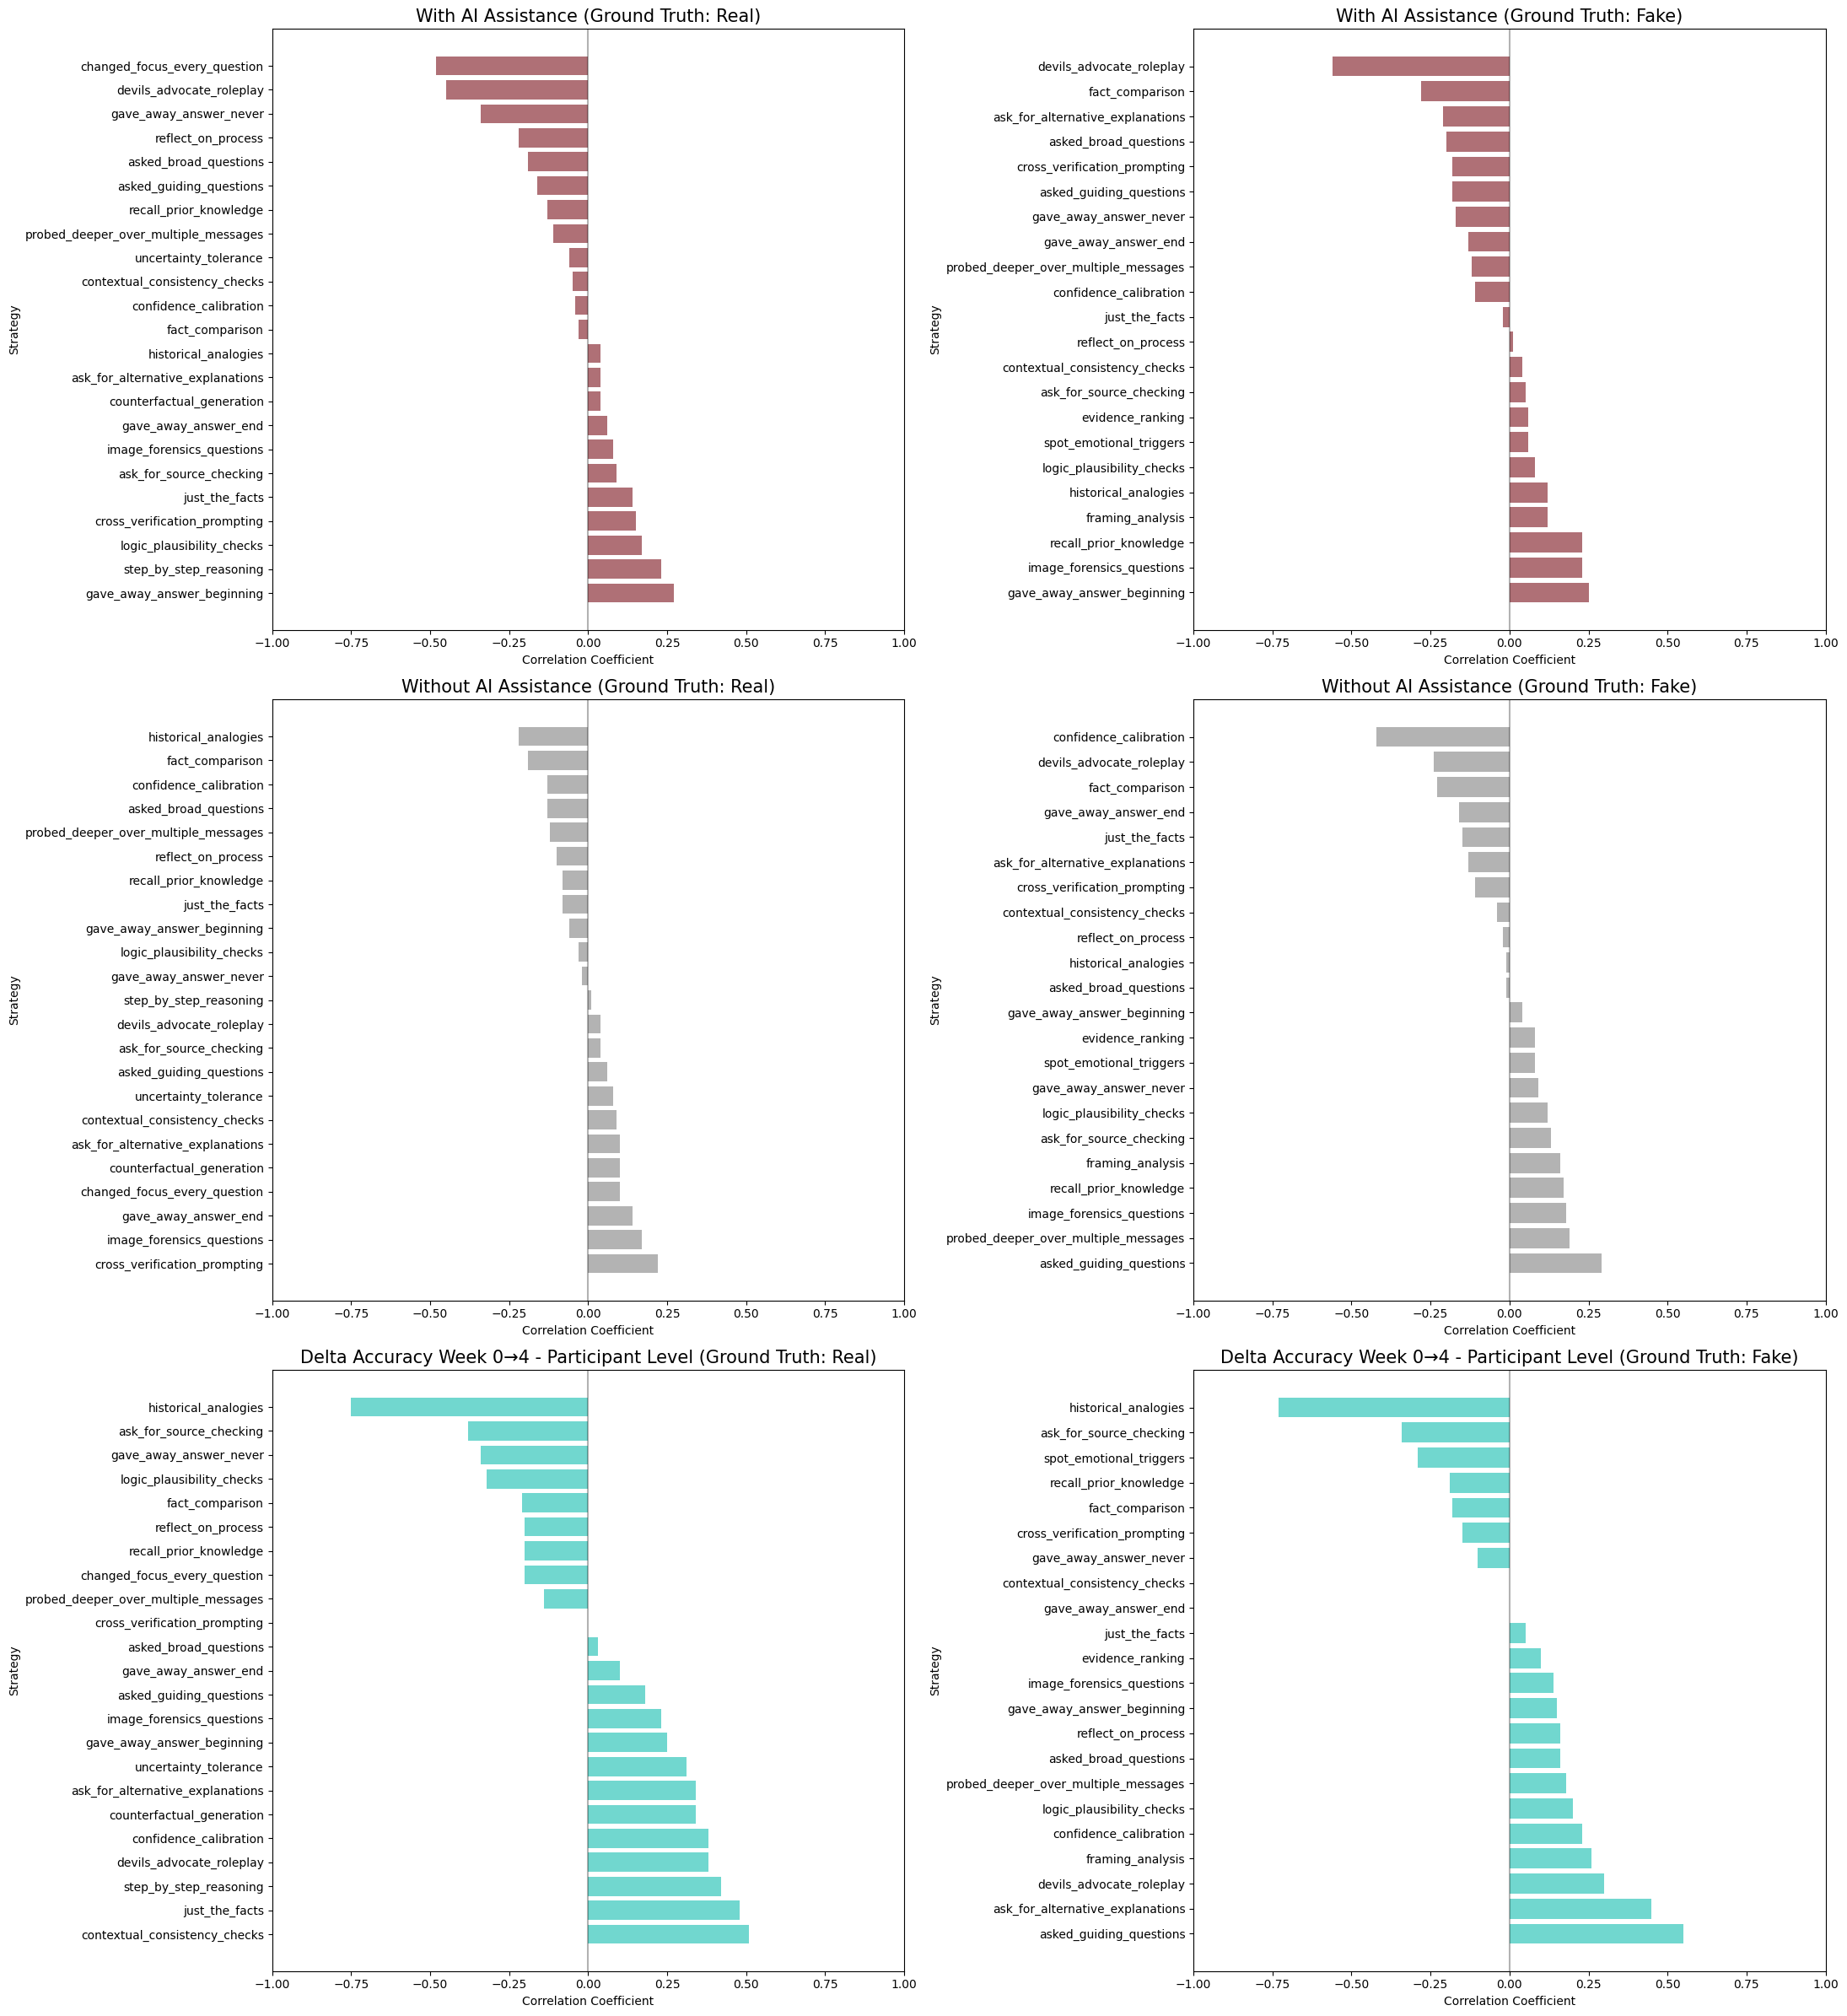

In [9]:
# print the correlation coefficients between accuracy and all strategies
# split by ground truth real vs. fake

# Calculate correlations between accuracy and all strategies, split by ground truth (Real vs. Fake)
correlations_with = {'Real': {}, 'Fake': {}}
correlations_unassisted = {'Real': {}, 'Fake': {}}
correlations_delta = {'Real': {}, 'Fake': {}}

# First, calculate participant-level delta accuracy from week 0 to week 4
participant_data_list = []
for participant_id in data['participant_id'].unique():
    participant_subset = data[data['participant_id'] == participant_id]
    
    # Get week 0 and week 4 data
    week0_data = participant_subset[participant_subset['week'] == 0]
    week4_data = participant_subset[participant_subset['week'] == 4]
    
    # Calculate average accuracy before for each week and ground truth
    for gt in ['Real', 'Fake']:
        week0_gt = week0_data[week0_data['ground_truth'] == gt]
        week4_gt = week4_data[week4_data['ground_truth'] == gt]
        
        if len(week0_gt) > 0 and len(week4_gt) > 0:
            # Calculate delta accuracy
            delta_accuracy = week4_gt['accuracy_before'].mean() - week0_gt['accuracy_before'].mean()
            
            # Calculate average strategy use across all weeks for this participant and ground truth
            participant_gt_data = participant_subset[participant_subset['ground_truth'] == gt]
            strategy_means = {}
            for category_name, category_dict in all_categories.items():
                for strategy in category_dict.keys():
                    if strategy in participant_gt_data.columns:
                        strategy_means[strategy] = pd.to_numeric(participant_gt_data[strategy], errors='coerce').mean()
            
            participant_data_list.append({
                'participant_id': participant_id,
                'ground_truth': gt,
                'delta_accuracy_before': delta_accuracy,
                **strategy_means
            })

participant_level_df = pd.DataFrame(participant_data_list)

# Calculate item-level correlations (existing code)
for gt in ['Real', 'Fake']:
    subset = data[data['ground_truth'] == gt]
    for category_name, category_dict in all_categories.items():
        for strategy in category_dict.keys():
            if strategy in subset.columns:
                corr_with = subset[['accuracy_with', strategy]].dropna()
                if not corr_with.empty:
                    corr = corr_with['accuracy_with'].corr(pd.to_numeric(corr_with[strategy], errors='coerce'))
                    correlations_with[gt][strategy] = round(corr, 2) if not pd.isna(corr) else np.nan
                else:
                    correlations_with[gt][strategy] = np.nan

                corr_unassist = subset[['accuracy_unassisted', strategy]].dropna()
                if not corr_unassist.empty:
                    corr_un = corr_unassist['accuracy_unassisted'].corr(pd.to_numeric(corr_unassist[strategy], errors='coerce'))
                    correlations_unassisted[gt][strategy] = round(corr_un, 2) if not pd.isna(corr_un) else np.nan
                else:
                    correlations_unassisted[gt][strategy] = np.nan

# Calculate participant-level delta correlations
for gt in ['Real', 'Fake']:
    participant_subset = participant_level_df[participant_level_df['ground_truth'] == gt]
    for category_name, category_dict in all_categories.items():
        for strategy in category_dict.keys():
            if strategy in participant_subset.columns:
                corr_delta = participant_subset[['delta_accuracy_before', strategy]].dropna()
                if not corr_delta.empty and len(corr_delta) > 2:
                    corr_d = corr_delta['delta_accuracy_before'].corr(pd.to_numeric(corr_delta[strategy], errors='coerce'))
                    correlations_delta[gt][strategy] = round(corr_d, 2) if not pd.isna(corr_d) else np.nan
                else:
                    correlations_delta[gt][strategy] = np.nan
            else:
                correlations_delta[gt][strategy] = np.nan

# Define a safe sorting key function that properly handles NaN values
def safe_sort_key(item):
    """Safe sorting key that handles NaN values properly"""
    value = item[1]
    if pd.isna(value):
        return -np.inf  # Put NaN values at the end (lowest)
    return value

# Sort for plotting (descending) for each ground truth group
# Using the improved sorting approach
fake_with_order = [k for k, v in sorted(correlations_with['Fake'].items(), key=safe_sort_key, reverse=True)]
fake_unassist_order = [k for k, v in sorted(correlations_unassisted['Fake'].items(), key=safe_sort_key, reverse=True)]
fake_delta_order = [k for k, v in sorted(correlations_delta['Fake'].items(), key=safe_sort_key, reverse=True)]
real_with_order = [k for k, v in sorted(correlations_with['Real'].items(), key=safe_sort_key, reverse=True)]
real_unassist_order = [k for k, v in sorted(correlations_unassisted['Real'].items(), key=safe_sort_key, reverse=True)]
real_delta_order = [k for k, v in sorted(correlations_delta['Real'].items(), key=safe_sort_key, reverse=True)]

# Reorder all dicts for plotting
correlations_with['Real'] = {k: correlations_with['Real'][k] for k in real_with_order}
correlations_with['Fake'] = {k: correlations_with['Fake'][k] for k in fake_with_order}
correlations_unassisted['Real'] = {k: correlations_unassisted['Real'][k] for k in real_unassist_order}
correlations_unassisted['Fake'] = {k: correlations_unassisted['Fake'][k] for k in fake_unassist_order}
correlations_delta['Real'] = {k: correlations_delta['Real'][k] for k in real_delta_order}
correlations_delta['Fake'] = {k: correlations_delta['Fake'][k] for k in fake_delta_order}

# Print sorted correlations to verify
print("Correlations with AI Assistance:")
for strategy in fake_with_order:
    corr_val = correlations_with['Fake'][strategy]
    if not pd.isna(corr_val):
        print(f"{strategy}: {corr_val}")

print("\nCorrelations without AI Assistance:")
for strategy in fake_unassist_order:
    corr_val = correlations_unassisted['Fake'][strategy]
    if not pd.isna(corr_val):
        print(f"{strategy}: {corr_val}")

print("\nCorrelations with Delta Accuracy (Week 0 to Week 4) - Participant Level:")
for strategy in fake_delta_order:
    corr_val = correlations_delta['Fake'][strategy]
    if not pd.isna(corr_val):
        print(f"{strategy}: {corr_val}")

# Plot
fig, axes = plt.subplots(3, 2, figsize=(22, 24))
titles = [
    "With AI Assistance (Ground Truth: Real)",
    "With AI Assistance (Ground Truth: Fake)",
    "Without AI Assistance (Ground Truth: Real)",
    "Without AI Assistance (Ground Truth: Fake)",
    "Delta Accuracy Week 0→4 - Participant Level (Ground Truth: Real)",
    "Delta Accuracy Week 0→4 - Participant Level (Ground Truth: Fake)"
]
plot_data = [
    correlations_with['Real'],
    correlations_with['Fake'],
    correlations_unassisted['Real'],
    correlations_unassisted['Fake'],
    correlations_delta['Real'],
    correlations_delta['Fake']
]

without_ai_color = '#A0A0A0'
with_ai_color = '#9B4C54'
delta_color = '#4ECDC4'

for i, ax in enumerate(axes.flat):
    plot_corr = {k: v for k, v in plot_data[i].items() if not pd.isna(v)}
    if i < 2:
        color = with_ai_color
    elif i < 4:
        color = without_ai_color
    else:
        color = delta_color
    
    ax.barh(list(plot_corr.keys()), list(plot_corr.values()), color=color, alpha=0.8)
    ax.set_title(titles[i], fontsize=15)
    ax.set_xlabel("Correlation Coefficient")
    ax.set_ylabel("Strategy")
    ax.set_xlim(-1, 1)
    ax.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        
plt.tight_layout()
plt.show()

/var/folders/p4/hpn1jhfx39bdjtyx1rrh_lrw0000gn/T/ipykernel_608/3667389416.py:139: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = stats.pearsonr(corr_with['accuracy_with'], pd.to_numeric(corr_with[strategy], errors='coerce'))
/var/folders/p4/hpn1jhfx39bdjtyx1rrh_lrw0000gn/T/ipykernel_608/3667389416.py:151: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_un, pval_un = stats.pearsonr(corr_unassist['accuracy_unassisted'], pd.to_numeric(corr_unassist[strategy], errors='coerce'))
/var/folders/p4/hpn1jhfx39bdjtyx1rrh_lrw0000gn/T/ipykernel_608/3667389416.py:163: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_b, pval_b = stats.pearsonr(corr_before['accuracy_before'], pd.to_numeric(corr_before[strategy], errors='coerce'))
/var/folders/p4/hpn1jhfx39bdjtyx1rrh_lrw0000gn/T/ipykernel_608/3667389416.py:139: ConstantInputWarning: An in

=== APPLYING RELIABILITY FILTERS ===
RELIABLE Correlations before AI Assistance (Fake News):
  asked_guiding_questions: 0.46 (occurs 83.3%, n=40, p=0.001) *
  reflect_on_process: 0.34 (occurs 43.8%, n=21, p=0.019) *
  asked_broad_questions: 0.29 (occurs 81.2%, n=39, p=0.046) *
  contextual_consistency_checks: 0.27 (occurs 33.3%, n=16, p=0.060)
  gave_away_answer_never: 0.25 (occurs 25.0%, n=12, p=0.089)
  logic_plausibility_checks: 0.24 (occurs 37.5%, n=18, p=0.094)
  probed_deeper_over_multiple_messages: 0.23 (occurs 91.7%, n=44, p=0.110)
  image_forensics_questions: 0.22 (occurs 22.9%, n=11, p=0.137)
  recall_prior_knowledge: 0.22 (occurs 68.8%, n=33, p=0.132)
  gave_away_answer_end: 0.12 (occurs 16.7%, n=8, p=0.434)
  just_the_facts: -0.06 (occurs 68.8%, n=33, p=0.695)
  ask_for_source_checking: -0.07 (occurs 18.8%, n=9, p=0.642)
  confidence_calibration: -0.18 (occurs 43.8%, n=21, p=0.210)
  devils_advocate_roleplay: -0.23 (occurs 12.5%, n=6, p=0.120)
  gave_away_answer_beginning: 

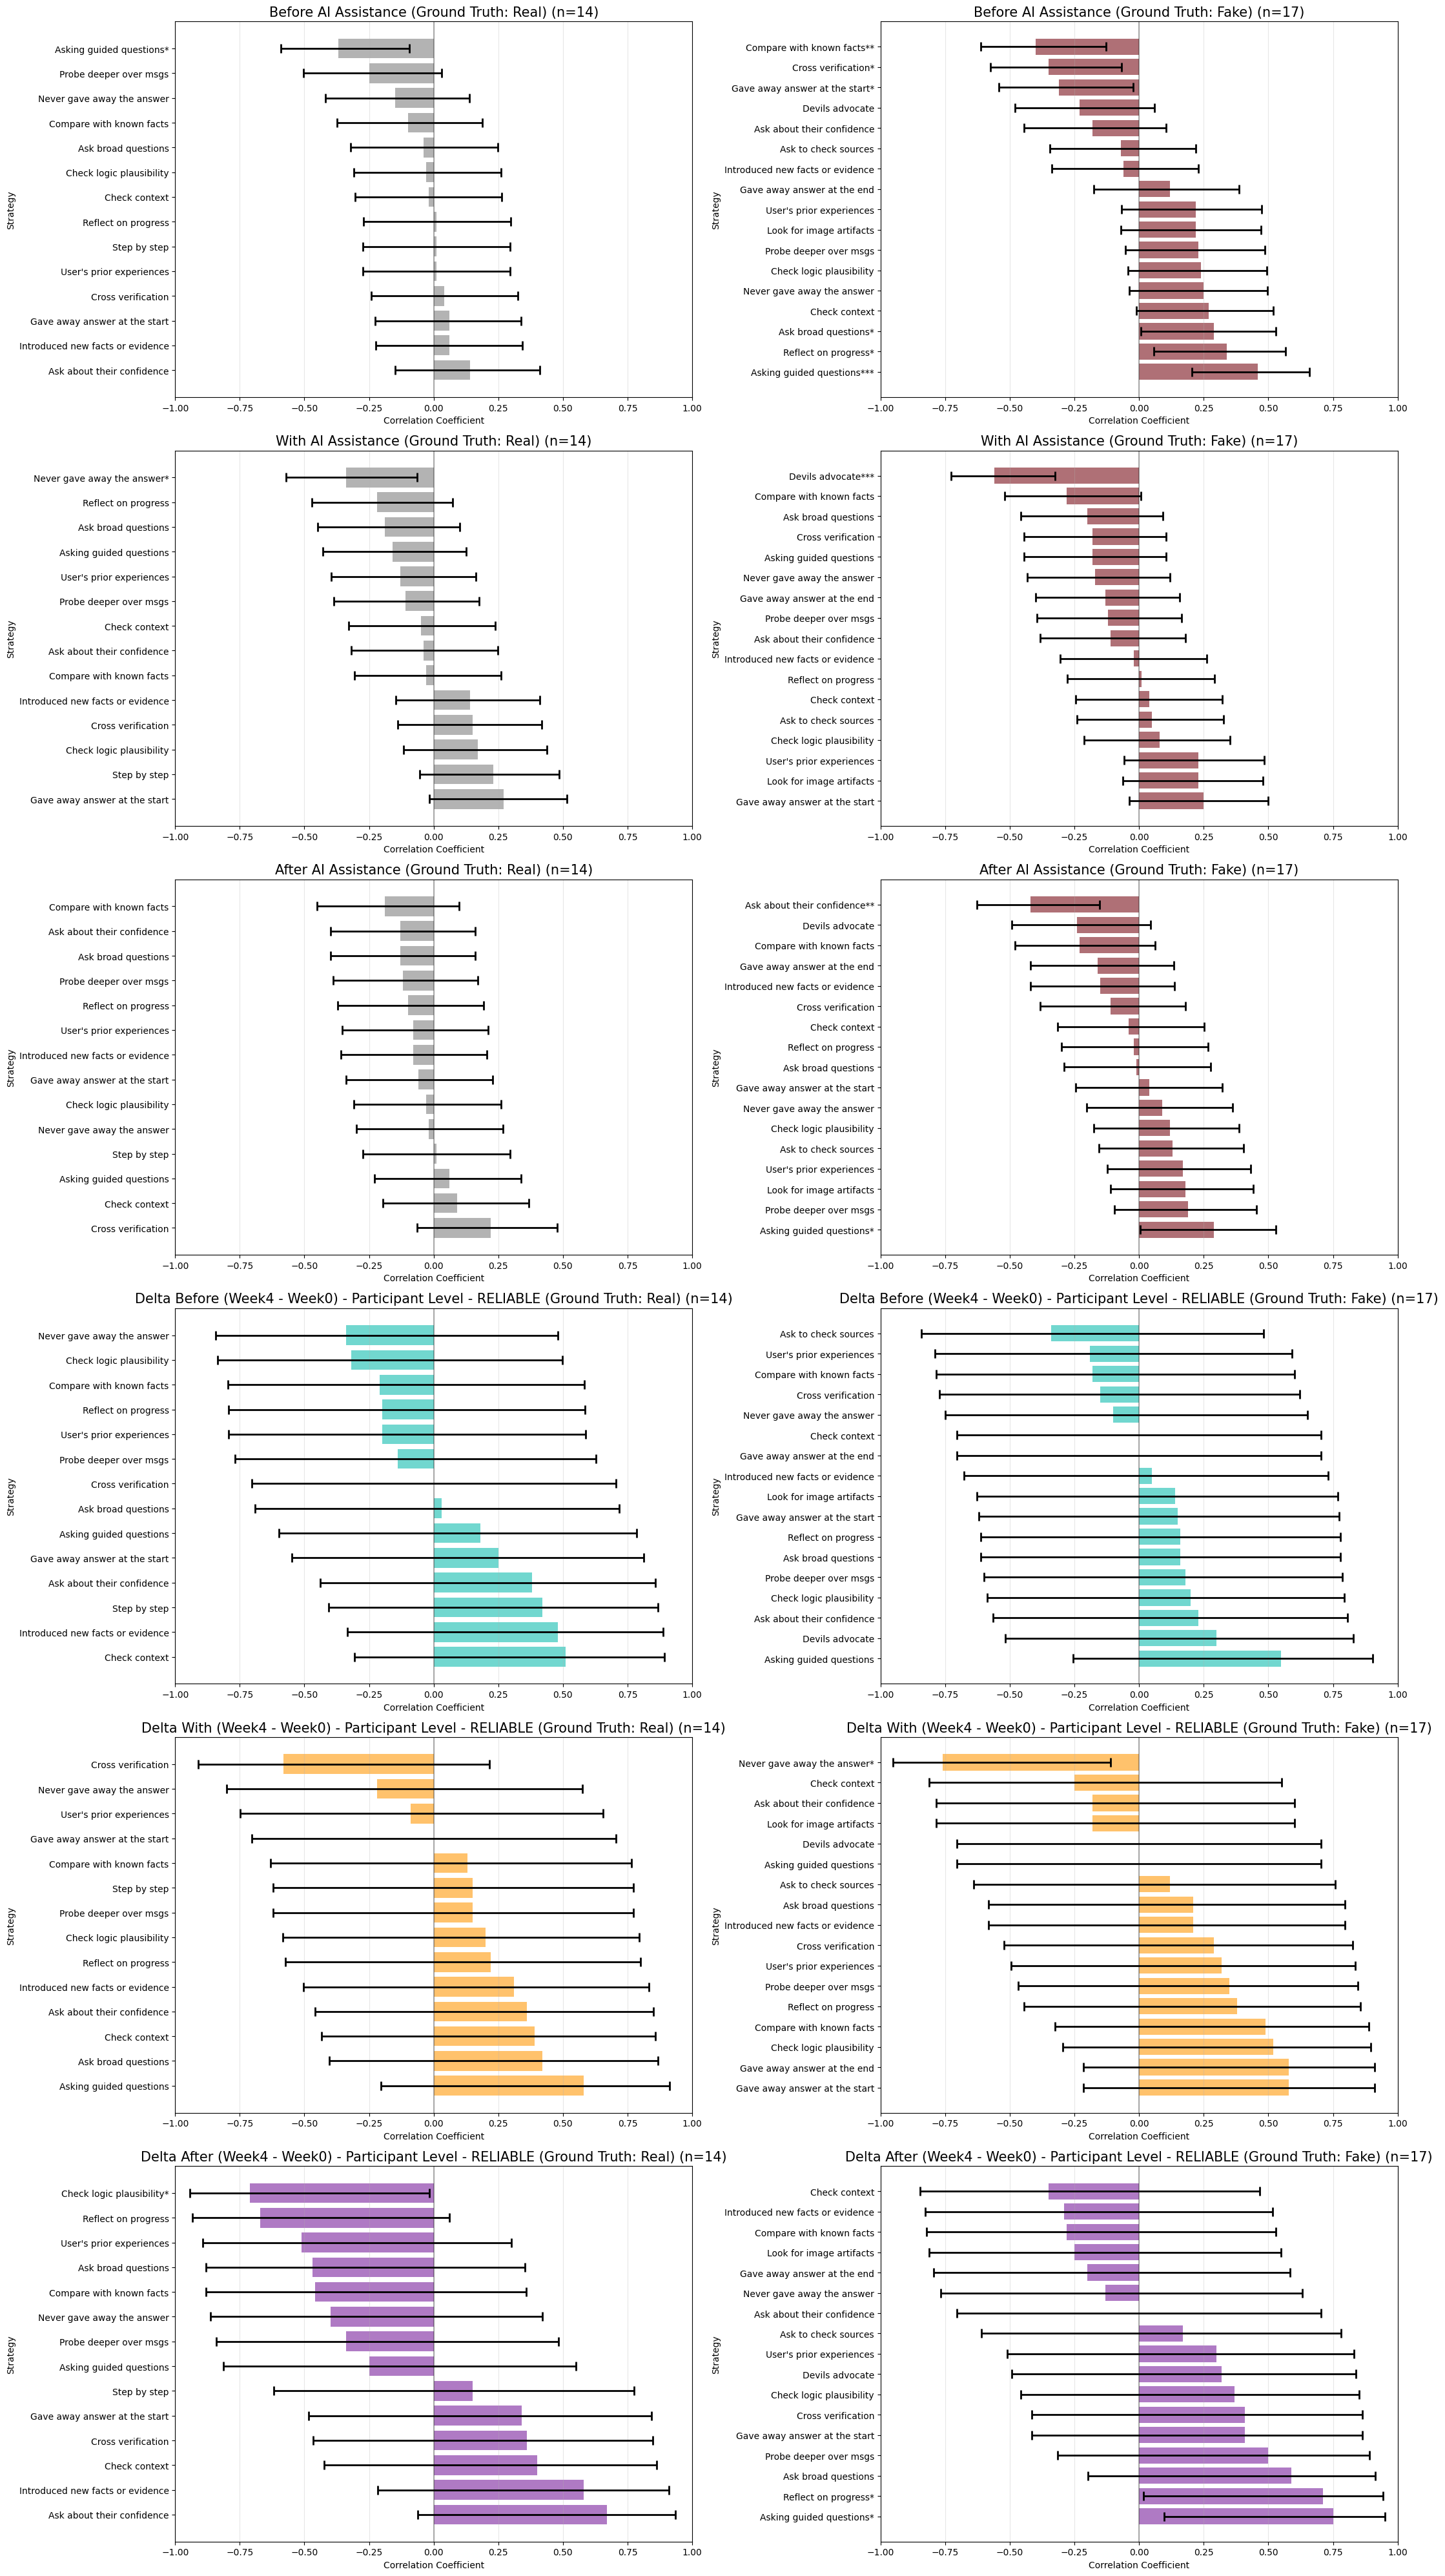

In [17]:
## Filter for occurrence rate between 5% and 95%, At least 10 positive cases, Sufficient variance (> 0.05)
# Create mapping for strategy display names
strategy_display_names = {
    'confidence_calibration': 'Ask about their confidence',
    'devils_advocate_roleplay': 'Devils advocate',
    'step_by_step_reasoning': 'Step by step',
    'fact_comparison': 'Compare with known facts',
    'cross_verification_prompting': 'Cross verification',
    'contextual_consistency_checks': 'Check context',
    'reflect_on_process': 'Reflect on progress',
    'historical_analogies': 'Align with history',
    'asked_broad_questions': 'Ask broad questions',
    'evidence_ranking': 'Rank evidence for claim',
    'spot_emotional_triggers': 'Spot emotional triggers',
    'bias_awareness_reflection': 'Bias awareness',
    'logic_plausibility_checks': 'Check logic plausibility',
    'ask_for_source_checking': 'Ask to check sources',
    'ask_for_alternative_explanations': 'Alternative explanations',
    'counterfactual_generation': 'Gave counterfactuals',
    'framing_analysis': 'Ask about framing',
    'recall_prior_knowledge': "User's prior experiences",
    'image_forensics_questions': 'Look for image artifacts',
    'probed_deeper_over_multiple_messages': 'Probe deeper over msgs',
    'asked_guiding_questions': 'Asking guided questions',
    'gave_away_answer_end': 'Gave away answer at the end',
    'gave_away_answer_beginning': 'Gave away answer at the start',
    'gave_away_answer_never': 'Never gave away the answer',
    'just_the_facts': 'Introduced new facts or evidence',
    'uncertainty_tolerance': 'State uncertainty'
}

# Calculate correlations between accuracy and all strategies, split by ground truth (Real vs. Fake)
correlations_before = {'Real': {}, 'Fake': {}}
correlations_with = {'Real': {}, 'Fake': {}}
correlations_unassisted = {'Real': {}, 'Fake': {}}
correlations_delta = {'Real': {}, 'Fake': {}}
correlations_with_participant = {'Real': {}, 'Fake': {}}
correlations_delta_unassisted = {'Real': {}, 'Fake': {}}

# Store p-values alongside correlations
pvalues_before = {'Real': {}, 'Fake': {}}
pvalues_with = {'Real': {}, 'Fake': {}}
pvalues_unassisted = {'Real': {}, 'Fake': {}}
pvalues_delta = {'Real': {}, 'Fake': {}}
pvalues_with_participant = {'Real': {}, 'Fake': {}}
pvalues_delta_unassisted = {'Real': {}, 'Fake': {}}

# Store confidence intervals (95%)
ci_before = {'Real': {}, 'Fake': {}}
ci_with = {'Real': {}, 'Fake': {}}
ci_unassisted = {'Real': {}, 'Fake': {}}
ci_delta = {'Real': {}, 'Fake': {}}
ci_with_participant = {'Real': {}, 'Fake': {}}
ci_delta_unassisted = {'Real': {}, 'Fake': {}}

def calculate_correlation_ci(r, n, confidence=0.95):
    """Calculate confidence interval for Pearson correlation using Fisher's z-transformation"""
    if pd.isna(r) or n < 3:
        return np.nan, np.nan
    
    # Fisher's z-transformation
    z = 0.5 * np.log((1 + r) / (1 - r))
    
    # Standard error
    se = 1 / np.sqrt(n - 3)
    
    # Critical value for 95% CI (two-tailed)
    z_crit = stats.norm.ppf((1 + confidence) / 2)
    
    # Confidence interval in z-space
    z_lower = z - z_crit * se
    z_upper = z + z_crit * se
    
    # Transform back to correlation space
    ci_lower = (np.exp(2 * z_lower) - 1) / (np.exp(2 * z_lower) + 1)
    ci_upper = (np.exp(2 * z_upper) - 1) / (np.exp(2 * z_upper) + 1)
    
    return ci_lower, ci_upper

# First, calculate participant-level delta accuracy from week 0 to week 4 AND participant-level accuracy_with
participant_data_list = []
for participant_id in data['participant_id'].unique():
    participant_subset = data[data['participant_id'] == participant_id]
    
    # Get week 0 and week 4 data
    week0_data = participant_subset[participant_subset['week'] == 0]
    week4_data = participant_subset[participant_subset['week'] == 4]
    
    # Calculate average accuracy before for each week and ground truth
    for gt in ['Real', 'Fake']:
        week0_gt = week0_data[week0_data['ground_truth'] == gt]
        week4_gt = week4_data[week4_data['ground_truth'] == gt]
        
        # Get all data for this participant and ground truth across all weeks
        participant_gt_data = participant_subset[participant_subset['ground_truth'] == gt]
        
        if len(participant_gt_data) > 0:
            # Calculate participant-level accuracy_with (average across all weeks)
            # participant_accuracy_with = participant_gt_data['accuracy_with'].mean()
            
            # Calculate delta accuracy (only if both week 0 and week 4 exist)
            # All deltas use baseline: accuracy_before_week0
            if len(week0_gt) > 0 and len(week4_gt) > 0:
                baseline_before_week0 = week0_gt['accuracy_before'].mean()
                delta_accuracy = week4_gt['accuracy_before'].mean() - baseline_before_week0
                participant_accuracy_with = week4_gt['accuracy_with'].mean() - baseline_before_week0
                delta_accuracy_unassisted = week4_gt['accuracy_unassisted'].mean() - baseline_before_week0
            else:
                delta_accuracy = np.nan
                participant_accuracy_with = np.nan
                delta_accuracy_unassisted = np.nan
            
            # Calculate average strategy use across all weeks for this participant and ground truth
            strategy_means = {}
            for category_name, category_dict in all_categories.items():
                for strategy in category_dict.keys():
                    if strategy in participant_gt_data.columns:
                        strategy_means[strategy] = pd.to_numeric(participant_gt_data[strategy], errors='coerce').mean()
            
            participant_data_list.append({
                'participant_id': participant_id,
                'ground_truth': gt,
                'delta_accuracy_before': delta_accuracy,
                'accuracy_with_participant': participant_accuracy_with,
                'delta_accuracy_unassisted': delta_accuracy_unassisted,
                **strategy_means
            })

participant_level_df = pd.DataFrame(participant_data_list)

# Calculate item-level correlations
for gt in ['Real', 'Fake']:
    subset = data[data['ground_truth'] == gt]
    for category_name, category_dict in all_categories.items():
        for strategy in category_dict.keys():
            if strategy in subset.columns:
                corr_with = subset[['accuracy_with', strategy]].dropna()
                if not corr_with.empty:
                    corr, pval = stats.pearsonr(corr_with['accuracy_with'], pd.to_numeric(corr_with[strategy], errors='coerce'))
                    correlations_with[gt][strategy] = round(corr, 2) if not pd.isna(corr) else np.nan
                    pvalues_with[gt][strategy] = pval if not pd.isna(pval) else np.nan
                    ci_l, ci_u = calculate_correlation_ci(corr, len(corr_with))
                    ci_with[gt][strategy] = (ci_l, ci_u)
                else:
                    correlations_with[gt][strategy] = np.nan
                    pvalues_with[gt][strategy] = np.nan
                    ci_with[gt][strategy] = (np.nan, np.nan)

                corr_unassist = subset[['accuracy_unassisted', strategy]].dropna()
                if not corr_unassist.empty:
                    corr_un, pval_un = stats.pearsonr(corr_unassist['accuracy_unassisted'], pd.to_numeric(corr_unassist[strategy], errors='coerce'))
                    correlations_unassisted[gt][strategy] = round(corr_un, 2) if not pd.isna(corr_un) else np.nan
                    pvalues_unassisted[gt][strategy] = pval_un if not pd.isna(pval_un) else np.nan
                    ci_l, ci_u = calculate_correlation_ci(corr_un, len(corr_unassist))
                    ci_unassisted[gt][strategy] = (ci_l, ci_u)
                else:
                    correlations_unassisted[gt][strategy] = np.nan
                    pvalues_unassisted[gt][strategy] = np.nan
                    ci_unassisted[gt][strategy] = (np.nan, np.nan)
                
                corr_before = subset[['accuracy_before', strategy]].dropna()
                if not corr_before.empty:
                    corr_b, pval_b = stats.pearsonr(corr_before['accuracy_before'], pd.to_numeric(corr_before[strategy], errors='coerce'))
                    correlations_before[gt][strategy] = round(corr_b, 2) if not pd.isna(corr_b) else np.nan
                    pvalues_before[gt][strategy] = pval_b if not pd.isna(pval_b) else np.nan
                    ci_l, ci_u = calculate_correlation_ci(corr_b, len(corr_before))
                    ci_before[gt][strategy] = (ci_l, ci_u)
                else:
                    correlations_before[gt][strategy] = np.nan
                    pvalues_before[gt][strategy] = np.nan
                    ci_before[gt][strategy] = (np.nan, np.nan)

# Calculate participant-level delta correlations
for gt in ['Real', 'Fake']:
    participant_subset = participant_level_df[participant_level_df['ground_truth'] == gt]
    for category_name, category_dict in all_categories.items():
        for strategy in category_dict.keys():
            if strategy in participant_subset.columns:
                corr_delta = participant_subset[['delta_accuracy_before', strategy]].dropna()
                if not corr_delta.empty and len(corr_delta) > 2:
                    corr_d, pval_d = stats.pearsonr(corr_delta['delta_accuracy_before'], pd.to_numeric(corr_delta[strategy], errors='coerce'))
                    correlations_delta[gt][strategy] = round(corr_d, 2) if not pd.isna(corr_d) else np.nan
                    pvalues_delta[gt][strategy] = pval_d if not pd.isna(pval_d) else np.nan
                    ci_l, ci_u = calculate_correlation_ci(corr_d, len(corr_delta))
                    ci_delta[gt][strategy] = (ci_l, ci_u)
                else:
                    correlations_delta[gt][strategy] = np.nan
                    pvalues_delta[gt][strategy] = np.nan
                    ci_delta[gt][strategy] = (np.nan, np.nan)
                    
                # Participant-level accuracy_with correlation
                corr_with_p = participant_subset[['accuracy_with_participant', strategy]].dropna()
                if not corr_with_p.empty and len(corr_with_p) > 2:
                    corr_wp, pval_wp = stats.pearsonr(corr_with_p['accuracy_with_participant'], pd.to_numeric(corr_with_p[strategy], errors='coerce'))
                    correlations_with_participant[gt][strategy] = round(corr_wp, 2) if not pd.isna(corr_wp) else np.nan
                    pvalues_with_participant[gt][strategy] = pval_wp if not pd.isna(pval_wp) else np.nan
                    ci_l, ci_u = calculate_correlation_ci(corr_wp, len(corr_with_p))
                    ci_with_participant[gt][strategy] = (ci_l, ci_u)
                else:
                    correlations_with_participant[gt][strategy] = np.nan
                    pvalues_with_participant[gt][strategy] = np.nan
                    ci_with_participant[gt][strategy] = (np.nan, np.nan)
                
                # Participant-level delta accuracy unassisted correlation
                corr_delta_un = participant_subset[['delta_accuracy_unassisted', strategy]].dropna()
                if not corr_delta_un.empty and len(corr_delta_un) > 2:
                    corr_dun, pval_dun = stats.pearsonr(corr_delta_un['delta_accuracy_unassisted'], pd.to_numeric(corr_delta_un[strategy], errors='coerce'))
                    correlations_delta_unassisted[gt][strategy] = round(corr_dun, 2) if not pd.isna(corr_dun) else np.nan
                    pvalues_delta_unassisted[gt][strategy] = pval_dun if not pd.isna(pval_dun) else np.nan
                    ci_l, ci_u = calculate_correlation_ci(corr_dun, len(corr_delta_un))
                    ci_delta_unassisted[gt][strategy] = (ci_l, ci_u)
                else:
                    correlations_delta_unassisted[gt][strategy] = np.nan
                    pvalues_delta_unassisted[gt][strategy] = np.nan
                    ci_delta_unassisted[gt][strategy] = (np.nan, np.nan)
            else:
                correlations_delta[gt][strategy] = np.nan
                correlations_with_participant[gt][strategy] = np.nan
                correlations_delta_unassisted[gt][strategy] = np.nan
                pvalues_delta[gt][strategy] = np.nan
                pvalues_with_participant[gt][strategy] = np.nan
                pvalues_delta_unassisted[gt][strategy] = np.nan
                ci_delta[gt][strategy] = (np.nan, np.nan)
                ci_with_participant[gt][strategy] = (np.nan, np.nan)
                ci_delta_unassisted[gt][strategy] = (np.nan, np.nan)

# Define a safe sorting key function that properly handles NaN values
def safe_sort_key(item):
    """Safe sorting key that handles NaN values properly"""
    value = item[1]
    if pd.isna(value):
        return -np.inf  # Put NaN values at the end (lowest)
    return value

# Sort for plotting (descending) for each ground truth group
# Using the improved sorting approach
fake_before_order = [k for k, v in sorted(correlations_before['Fake'].items(), key=safe_sort_key, reverse=True)]
fake_with_order = [k for k, v in sorted(correlations_with['Fake'].items(), key=safe_sort_key, reverse=True)]
fake_unassist_order = [k for k, v in sorted(correlations_unassisted['Fake'].items(), key=safe_sort_key, reverse=True)]
fake_delta_order = [k for k, v in sorted(correlations_delta['Fake'].items(), key=safe_sort_key, reverse=True)]
fake_with_p_order = [k for k, v in sorted(correlations_with_participant['Fake'].items(), key=safe_sort_key, reverse=True)]
fake_delta_un_order = [k for k, v in sorted(correlations_delta_unassisted['Fake'].items(), key=safe_sort_key, reverse=True)]
real_before_order = [k for k, v in sorted(correlations_before['Real'].items(), key=safe_sort_key, reverse=True)]
real_with_order = [k for k, v in sorted(correlations_with['Real'].items(), key=safe_sort_key, reverse=True)]
real_unassist_order = [k for k, v in sorted(correlations_unassisted['Real'].items(), key=safe_sort_key, reverse=True)]
real_delta_order = [k for k, v in sorted(correlations_delta['Real'].items(), key=safe_sort_key, reverse=True)]
real_with_p_order = [k for k, v in sorted(correlations_with_participant['Real'].items(), key=safe_sort_key, reverse=True)]
real_delta_un_order = [k for k, v in sorted(correlations_delta_unassisted['Real'].items(), key=safe_sort_key, reverse=True)]

# Reorder all dicts for plotting
correlations_before['Real'] = {k: correlations_before['Real'][k] for k in real_before_order}
correlations_before['Fake'] = {k: correlations_before['Fake'][k] for k in fake_before_order}
correlations_with['Real'] = {k: correlations_with['Real'][k] for k in real_with_order}
correlations_with['Fake'] = {k: correlations_with['Fake'][k] for k in fake_with_order}
correlations_unassisted['Real'] = {k: correlations_unassisted['Real'][k] for k in real_unassist_order}
correlations_unassisted['Fake'] = {k: correlations_unassisted['Fake'][k] for k in fake_unassist_order}
correlations_delta['Real'] = {k: correlations_delta['Real'][k] for k in real_delta_order}
correlations_delta['Fake'] = {k: correlations_delta['Fake'][k] for k in fake_delta_order}
correlations_with_participant['Real'] = {k: correlations_with_participant['Real'][k] for k in real_with_p_order}
correlations_with_participant['Fake'] = {k: correlations_with_participant['Fake'][k] for k in fake_with_p_order}
correlations_delta_unassisted['Real'] = {k: correlations_delta_unassisted['Real'][k] for k in real_delta_un_order}
correlations_delta_unassisted['Fake'] = {k: correlations_delta_unassisted['Fake'][k] for k in fake_delta_un_order}

# Apply reliability filters to identify trustworthy correlations
print("=== APPLYING RELIABILITY FILTERS ===")

# Calculate occurrence rates and variance for filtering
occurrence_rates = {}
variance_analysis = {}

for gt in ['Real', 'Fake']:
    subset = data[data['ground_truth'] == gt]
    occurrence_rates[gt] = {}
    variance_analysis[gt] = {}
    
    for category_name, category_dict in all_categories.items():
        for strategy in category_dict.keys():
            if strategy in subset.columns:
                strategy_col = pd.to_numeric(subset[strategy], errors='coerce')
                occurrence_rate = strategy_col.mean()
                n_positive = (strategy_col == 1).sum()
                variance = strategy_col.var()
                
                occurrence_rates[gt][strategy] = occurrence_rate
                variance_analysis[gt][strategy] = {
                    'variance': variance,
                    'n_positive': n_positive
                }

# Filter correlations based on reliability criteria
def filter_reliable_correlations(correlations_dict, gt):
    """Filter correlations to only include reliable strategies"""
    reliable_corr = {}
    for strategy, corr_val in correlations_dict.items():
        if strategy in occurrence_rates[gt]:
            occ_rate = occurrence_rates[gt][strategy]
            n_pos = variance_analysis[gt][strategy]['n_positive']
            variance = variance_analysis[gt][strategy]['variance']
            
            # Apply reliability criteria
            if (0.05 <= occ_rate <= 0.95 and 
                n_pos >= 5 and 
                variance > 0.05 and 
                not pd.isna(corr_val)):
                reliable_corr[strategy] = corr_val
    return reliable_corr

# For delta correlations, we need a special filter since it's at participant level
def filter_reliable_delta_correlations(correlations_dict, gt):
    """Filter delta correlations - uses item-level occurrence rates but participant-level correlations"""
    reliable_corr = {}
    for strategy, corr_val in correlations_dict.items():
        if strategy in occurrence_rates[gt]:
            occ_rate = occurrence_rates[gt][strategy]
            n_pos = variance_analysis[gt][strategy]['n_positive']
            variance = variance_analysis[gt][strategy]['variance']
            
            # Apply reliability criteria (same as item-level)
            if (0.05 <= occ_rate <= 0.95 and 
                n_pos >= 5 and 
                variance > 0.05 and 
                not pd.isna(corr_val)):
                reliable_corr[strategy] = corr_val
    return reliable_corr

# Apply filters to all correlation dictionaries
filtered_correlations_before = {
    'Real': filter_reliable_correlations(correlations_before['Real'], 'Real'),
    'Fake': filter_reliable_correlations(correlations_before['Fake'], 'Fake')
}

filtered_correlations_with = {
    'Real': filter_reliable_correlations(correlations_with['Real'], 'Real'),
    'Fake': filter_reliable_correlations(correlations_with['Fake'], 'Fake')
}

filtered_correlations_unassisted = {
    'Real': filter_reliable_correlations(correlations_unassisted['Real'], 'Real'),
    'Fake': filter_reliable_correlations(correlations_unassisted['Fake'], 'Fake')
}

filtered_correlations_delta = {
    'Real': filter_reliable_delta_correlations(correlations_delta['Real'], 'Real'),
    'Fake': filter_reliable_delta_correlations(correlations_delta['Fake'], 'Fake')
}

filtered_correlations_with_participant = {
    'Real': filter_reliable_delta_correlations(correlations_with_participant['Real'], 'Real'),
    'Fake': filter_reliable_delta_correlations(correlations_with_participant['Fake'], 'Fake')
}

filtered_correlations_delta_unassisted = {
    'Real': filter_reliable_delta_correlations(correlations_delta_unassisted['Real'], 'Real'),
    'Fake': filter_reliable_delta_correlations(correlations_delta_unassisted['Fake'], 'Fake')
}

# Sort filtered correlations
for gt in ['Real', 'Fake']:
    filtered_correlations_before[gt] = dict(sorted(filtered_correlations_before[gt].items(), key=lambda x: x[1], reverse=True))
    filtered_correlations_with[gt] = dict(sorted(filtered_correlations_with[gt].items(), key=lambda x: x[1], reverse=True))
    filtered_correlations_unassisted[gt] = dict(sorted(filtered_correlations_unassisted[gt].items(), key=lambda x: x[1], reverse=True))
    filtered_correlations_delta[gt] = dict(sorted(filtered_correlations_delta[gt].items(), key=lambda x: x[1], reverse=True))
    filtered_correlations_with_participant[gt] = dict(sorted(filtered_correlations_with_participant[gt].items(), key=lambda x: x[1], reverse=True))
    filtered_correlations_delta_unassisted[gt] = dict(sorted(filtered_correlations_delta_unassisted[gt].items(), key=lambda x: x[1], reverse=True))

# Print filtered correlations
print("RELIABLE Correlations before AI Assistance (Fake News):")
for strategy, corr_val in filtered_correlations_before['Fake'].items():
    occ_rate = occurrence_rates['Fake'][strategy]
    n_pos = variance_analysis['Fake'][strategy]['n_positive']
    pval = pvalues_before['Fake'][strategy]
    pval_str = f", p={pval:.3f}" if not pd.isna(pval) else ""
    sig_marker = " *" if not pd.isna(pval) and pval < 0.05 else ""
    print(f"  {strategy}: {corr_val} (occurs {occ_rate:.1%}, n={n_pos}{pval_str}){sig_marker}")

print("\nRELIABLE Correlations with AI Assistance (Fake News):")
for strategy, corr_val in filtered_correlations_with['Fake'].items():
    occ_rate = occurrence_rates['Fake'][strategy]
    n_pos = variance_analysis['Fake'][strategy]['n_positive']
    pval = pvalues_with['Fake'][strategy]
    pval_str = f", p={pval:.3f}" if not pd.isna(pval) else ""
    sig_marker = " *" if not pd.isna(pval) and pval < 0.05 else ""
    print(f"  {strategy}: {corr_val} (occurs {occ_rate:.1%}, n={n_pos}{pval_str}){sig_marker}")

print(f"\nRELIABLE Correlations without AI Assistance (Fake News):")
for strategy, corr_val in filtered_correlations_unassisted['Fake'].items():
    occ_rate = occurrence_rates['Fake'][strategy]
    n_pos = variance_analysis['Fake'][strategy]['n_positive']
    pval = pvalues_unassisted['Fake'][strategy]
    pval_str = f", p={pval:.3f}" if not pd.isna(pval) else ""
    sig_marker = " *" if not pd.isna(pval) and pval < 0.05 else ""
    print(f"  {strategy}: {corr_val} (occurs {occ_rate:.1%}, n={n_pos}{pval_str}){sig_marker}")

print(f"\nRELIABLE Correlations with Delta Accuracy Week 0→4 - Participant Level (Fake News):")
for strategy, corr_val in filtered_correlations_delta['Fake'].items():
    occ_rate = occurrence_rates['Fake'][strategy]
    n_pos = variance_analysis['Fake'][strategy]['n_positive']
    pval = pvalues_delta['Fake'][strategy]
    pval_str = f", p={pval:.3f}" if not pd.isna(pval) else ""
    sig_marker = " *" if not pd.isna(pval) and pval < 0.05 else ""
    print(f"  {strategy}: {corr_val} (occurs {occ_rate:.1%}, n={n_pos}{pval_str}){sig_marker}")

print(f"\nRELIABLE Correlations with Accuracy (With AI) - Participant Level (Fake News):")
for strategy, corr_val in filtered_correlations_with_participant['Fake'].items():
    occ_rate = occurrence_rates['Fake'][strategy]
    n_pos = variance_analysis['Fake'][strategy]['n_positive']
    pval = pvalues_with_participant['Fake'][strategy]
    pval_str = f", p={pval:.3f}" if not pd.isna(pval) else ""
    sig_marker = " *" if not pd.isna(pval) and pval < 0.05 else ""
    print(f"  {strategy}: {corr_val} (occurs {occ_rate:.1%}, n={n_pos}{pval_str}){sig_marker}")

print(f"\nRELIABLE Correlations with Delta Accuracy Unassisted Week 0→4 - Participant Level (Fake News):")
for strategy, corr_val in filtered_correlations_delta_unassisted['Fake'].items():
    occ_rate = occurrence_rates['Fake'][strategy]
    n_pos = variance_analysis['Fake'][strategy]['n_positive']
    pval = pvalues_delta_unassisted['Fake'][strategy]
    pval_str = f", p={pval:.3f}" if not pd.isna(pval) else ""
    sig_marker = " *" if not pd.isna(pval) and pval < 0.05 else ""
    print(f"  {strategy}: {corr_val} (occurs {occ_rate:.1%}, n={n_pos}{pval_str}){sig_marker}")

print(f"\nFiltered out {len(correlations_with['Fake']) - len(filtered_correlations_with['Fake'])} unreliable strategies for Fake news")
print(f"Kept {len(filtered_correlations_with['Fake'])} reliable strategies for analysis")

# Plot FILTERED correlations
fig, axes = plt.subplots(6, 2, figsize=(22, 40))
titles = [
    "Before AI Assistance (Ground Truth: Real)",
    "Before AI Assistance (Ground Truth: Fake)",
    "With AI Assistance (Ground Truth: Real)",
    "With AI Assistance (Ground Truth: Fake)",
    "After AI Assistance (Ground Truth: Real)",
    "After AI Assistance (Ground Truth: Fake)",
    "Delta Before (Week4 - Week0) - Participant Level - RELIABLE (Ground Truth: Real)",
    "Delta Before (Week4 - Week0) - Participant Level - RELIABLE (Ground Truth: Fake)",
    "Delta With (Week4 - Week0) - Participant Level - RELIABLE (Ground Truth: Real)",
    "Delta With (Week4 - Week0) - Participant Level - RELIABLE (Ground Truth: Fake)",
    "Delta After (Week4 - Week0) - Participant Level - RELIABLE (Ground Truth: Real)",
    "Delta After (Week4 - Week0) - Participant Level - RELIABLE (Ground Truth: Fake)"
]
plot_data = [
    filtered_correlations_before['Real'],
    filtered_correlations_before['Fake'],
    filtered_correlations_with['Real'],
    filtered_correlations_with['Fake'],
    filtered_correlations_unassisted['Real'],
    filtered_correlations_unassisted['Fake'],
    filtered_correlations_delta['Real'],
    filtered_correlations_delta['Fake'],
    filtered_correlations_with_participant['Real'],
    filtered_correlations_with_participant['Fake'],
    filtered_correlations_delta_unassisted['Real'],
    filtered_correlations_delta_unassisted['Fake']
]

ci_data = [
    ci_before['Real'],
    ci_before['Fake'],
    ci_with['Real'],
    ci_with['Fake'],
    ci_unassisted['Real'],
    ci_unassisted['Fake'],
    ci_delta['Real'],
    ci_delta['Fake'],
    ci_with_participant['Real'],
    ci_with_participant['Fake'],
    ci_delta_unassisted['Real'],
    ci_delta_unassisted['Fake']
]

true_color = '#A0A0A0'
fake_color = '#9B4C54'
delta_color = '#4ECDC4'
participant_color = '#FFB347'
unassisted_delta_color = '#9B59B6'

# Get p-value dictionaries for current plot
pvalue_dicts = [
    pvalues_before['Real'],
    pvalues_before['Fake'],
    pvalues_with['Real'],
    pvalues_with['Fake'],
    pvalues_unassisted['Real'],
    pvalues_unassisted['Fake'],
    pvalues_delta['Real'],
    pvalues_delta['Fake'],
    pvalues_with_participant['Real'],
    pvalues_with_participant['Fake'],
    pvalues_delta_unassisted['Real'],
    pvalues_delta_unassisted['Fake']
]

for i, ax in enumerate(axes.flat):
    plot_corr = plot_data[i]
    ci_corr = ci_data[i]
    pvalue_dict = pvalue_dicts[i]
    
    if plot_corr:  # Only plot if there are reliable correlations
        # Choose color based on row
        if i < 6:
            color = true_color if i % 2 == 0 else fake_color
        elif i < 8:
            color = delta_color
        elif i < 10:
            color = participant_color
        else:
            color = unassisted_delta_color
        
        # Prepare data and error bars for plotting
        strategies = list(plot_corr.keys())
        corrs = list(plot_corr.values())
        
        # Add significance markers and display names to strategy names
        strategies_with_sig = []
        for strategy in strategies:
            # Get display name
            display_name = strategy_display_names.get(strategy, strategy)
            
            if strategy in pvalue_dict:
                pval = pvalue_dict[strategy]
                if not pd.isna(pval):
                    if pval < 0.001:
                        strategies_with_sig.append(f"{display_name}***")
                    elif pval < 0.01:
                        strategies_with_sig.append(f"{display_name}**")
                    elif pval < 0.05:
                        strategies_with_sig.append(f"{display_name}*")
                    else:
                        strategies_with_sig.append(display_name)
                else:
                    strategies_with_sig.append(display_name)
            else:
                strategies_with_sig.append(display_name)
        
        # Calculate error bars from confidence intervals
        errors = []
        for strategy in strategies:
            if strategy in ci_corr and ci_corr[strategy] != (np.nan, np.nan):
                ci_lower, ci_upper = ci_corr[strategy]
                corr_val = plot_corr[strategy]
                # Error bar is the distance from point to CI bounds
                error_lower = corr_val - ci_lower
                error_upper = ci_upper - corr_val
                errors.append([error_lower, error_upper])
            else:
                errors.append([0, 0])
        
        # Transpose errors for xerr format (needs [lower_errors, upper_errors])
        if errors:
            errors_lower = [e[0] for e in errors]
            errors_upper = [e[1] for e in errors]
            ax.barh(strategies_with_sig, corrs, xerr=[errors_lower, errors_upper],
                    color=color, alpha=0.8, capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})
        else:
            ax.barh(strategies_with_sig, corrs, color=color, alpha=0.8)
        ax.set_title(f"{titles[i]} (n={len(plot_corr)})", fontsize=15)
        ax.set_xlabel("Correlation Coefficient")
        ax.set_ylabel("Strategy")
        ax.set_xlim(-1, 1)
        ax.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        
        # Add grid for better readability
        ax.grid(axis='x', alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No reliable correlations\nmeet filtering criteria', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(titles[i], fontsize=15)

plt.tight_layout()
plt.show()

=== STRATEGY TRADE-OFF ANALYSIS ===
Comparing performance WITH AI vs performance AFTER AI (unassisted)

Strategy Categories by News Type:

Real News:
  AI Dependent: 6 strategies
  Learning Transfer: 5 strategies
  Consistent: 3 strategies

Fake News:
  Learning Transfer: 9 strategies
  AI Dependent: 4 strategies
  Consistent: 4 strategies


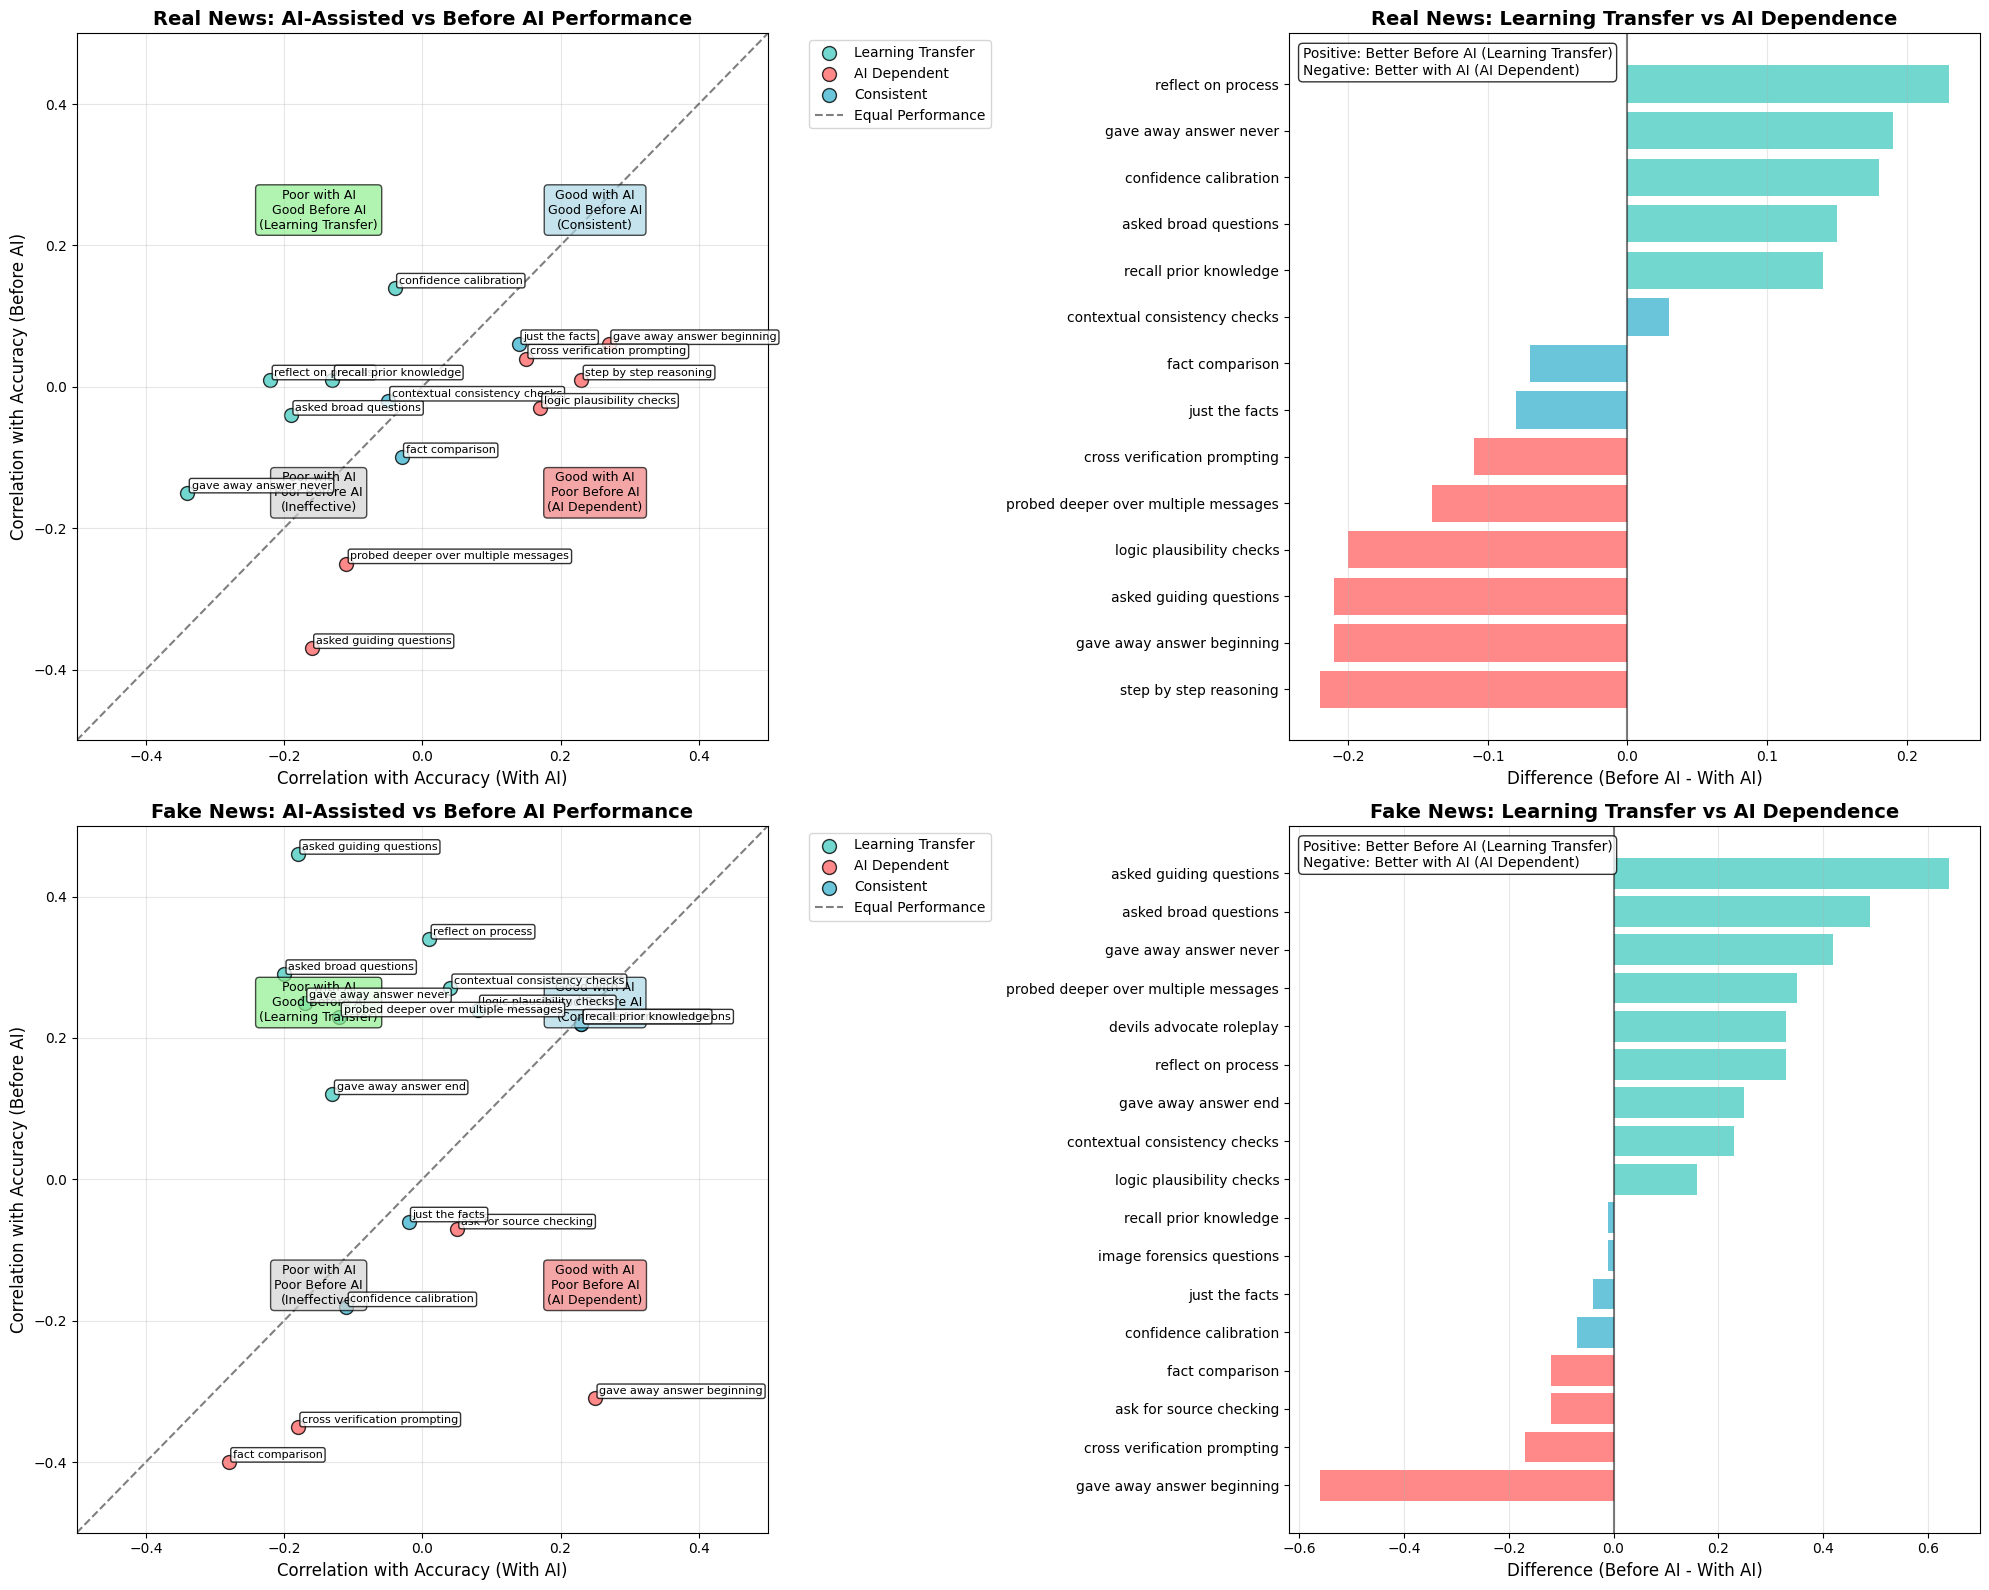


=== DETAILED TRADE-OFF ANALYSIS ===

--- Real News Trade-offs ---

🎓 LEARNING TRANSFER (Better before AI than with AI - skills transfer):
  reflect_on_process: With AI=-0.22, Before AI=0.01 (diff=+0.23, std=0.41)
  gave_away_answer_never: With AI=-0.34, Before AI=-0.15 (diff=+0.19, std=0.33)
  confidence_calibration: With AI=-0.04, Before AI=0.14 (diff=+0.18, std=0.50)
  asked_broad_questions: With AI=-0.19, Before AI=-0.04 (diff=+0.15, std=0.50)
  recall_prior_knowledge: With AI=-0.13, Before AI=0.01 (diff=+0.14, std=0.50)

🤖 AI DEPENDENT (Better with AI than before AI - may create dependence):
  step_by_step_reasoning: With AI=0.23, Before AI=0.01 (diff=-0.22, std=0.24)
  gave_away_answer_beginning: With AI=0.27, Before AI=0.06 (diff=-0.21, std=0.38)
  asked_guiding_questions: With AI=-0.16, Before AI=-0.37 (diff=-0.21, std=0.42)
  logic_plausibility_checks: With AI=0.17, Before AI=-0.03 (diff=-0.20, std=0.44)
  probed_deeper_over_multiple_messages: With AI=-0.11, Before AI=-0.25 (d

In [10]:
# Strategy Trade-off Analysis: Performance with AI vs Performance after AI
# Compare "with AI" correlations vs "unassisted (after)" correlations to identify trade-offs

# Check if required variables exist
try:
    test_var = filtered_correlations_with
    print("=== STRATEGY TRADE-OFF ANALYSIS ===")
    print("Comparing performance WITH AI vs performance AFTER AI (unassisted)\n")
except NameError:
    print("ERROR: Please run the previous cell (with reliability filtering) first to define the filtered correlations.")
    print("The variables 'filtered_correlations_with' and 'filtered_correlations_unassisted' need to be defined.")
    # Stop execution here
    raise NameError("Required variables not defined. Run the reliability filtering cell first.")

# Create comparison dataframes for analysis
comparison_data = []

for gt in ['Real', 'Fake']:
    # Get overlapping strategies (those in both filtered sets)
    before_ai_strategies = set(filtered_correlations_before[gt].keys())
    with_ai_strategies = set(filtered_correlations_with[gt].keys())
    
    # Only analyze strategies that appear in both analyses (for fair comparison)
    common_strategies = with_ai_strategies.intersection(before_ai_strategies)
    
    for strategy in common_strategies:
        with_ai_corr = filtered_correlations_with[gt][strategy]
        before_ai_corr = filtered_correlations_before[gt][strategy]
        
        comparison_data.append({
            'strategy': strategy,
            'ground_truth': gt,
            'with_ai_correlation': with_ai_corr,
            'before_ai_correlation': before_ai_corr,
            'difference': before_ai_corr - with_ai_corr,  # Positive = better before AI than during AI
            'category': 'Learning Transfer' if before_ai_corr > with_ai_corr + 0.1 else 
                       'AI Dependent' if with_ai_corr > before_ai_corr + 0.1 else 
                       'Consistent'
        })

comparison_df = pd.DataFrame(comparison_data)

# Print summary statistics
print("Strategy Categories by News Type:")
for gt in ['Real', 'Fake']:
    subset = comparison_df[comparison_df['ground_truth'] == gt]
    print(f"\n{gt} News:")
    category_counts = subset['category'].value_counts()
    for category, count in category_counts.items():
        print(f"  {category}: {count} strategies")

# Create the trade-off visualization
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

for gt_idx, gt in enumerate(['Real', 'Fake']):
    subset = comparison_df[comparison_df['ground_truth'] == gt]
    
    # Scatter plot: With AI vs Before AI correlations
    ax1 = axes[gt_idx, 0]
    
    # Color code by category
    colors = {'Learning Transfer': '#4ECDC4', 'AI Dependent': '#FF6B6B', 'Consistent': '#45B7D1'}
    
    for category in subset['category'].unique():
        cat_data = subset[subset['category'] == category]
        ax1.scatter(cat_data['with_ai_correlation'], cat_data['before_ai_correlation'], 
                   c=colors[category], label=category, alpha=0.8, s=100, edgecolors='black')
    
    # Add diagonal line (where with_ai = before_ai)
    ax1.plot([-0.5, 0.5], [-0.5, 0.5], 'k--', alpha=0.5, label='Equal Performance')
    
    # Add quadrant labels
    ax1.text(0.25, -0.15, 'Good with AI\nPoor Before AI\n(AI Dependent)', ha='center', va='center', 
             bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7), fontsize=9)
    ax1.text(-0.15, 0.25, 'Poor with AI\nGood Before AI\n(Learning Transfer)', ha='center', va='center',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7), fontsize=9)
    ax1.text(0.25, 0.25, 'Good with AI\nGood Before AI\n(Consistent)', ha='center', va='center',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7), fontsize=9)
    ax1.text(-0.15, -0.15, 'Poor with AI\nPoor Before AI\n(Ineffective)', ha='center', va='center',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.7), fontsize=9)
    
    ax1.set_xlabel('Correlation with Accuracy (With AI)', fontsize=12)
    ax1.set_ylabel('Correlation with Accuracy (Before AI)', fontsize=12)
    ax1.set_title(f'{gt} News: AI-Assisted vs Before AI Performance', fontsize=14, fontweight='bold')
    ax1.set_xlim(-0.5, 0.5)
    ax1.set_ylim(-0.5, 0.5)
    ax1.grid(True, alpha=0.3)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add strategy labels for all strategies
    for _, row in subset.iterrows():
        ax1.annotate(row['strategy'].replace('_', ' '), 
                    (row['with_ai_correlation'], row['before_ai_correlation']),
                    xytext=(3, 3), textcoords='offset points', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
    
    # Bar plot: Difference (Before AI - With AI)
    ax2 = axes[gt_idx, 1]
    
    # Sort by difference
    subset_sorted = subset.sort_values('difference', ascending=True)
    colors_list = [colors[cat] for cat in subset_sorted['category']]
    
    bars = ax2.barh(range(len(subset_sorted)), subset_sorted['difference'], 
                    color=colors_list, alpha=0.8)
    
    ax2.set_yticks(range(len(subset_sorted)))
    ax2.set_yticklabels([s.replace('_', ' ') for s in subset_sorted['strategy']], fontsize=10)
    ax2.set_xlabel('Difference (Before AI - With AI)', fontsize=12)
    ax2.set_title(f'{gt} News: Learning Transfer vs AI Dependence', fontsize=14, fontweight='bold')
    ax2.axvline(x=0, color='black', linestyle='-', alpha=0.5)
    ax2.grid(axis='x', alpha=0.3)
    
    # Add interpretation text
    ax2.text(0.02, 0.98, 'Positive: Better Before AI (Learning Transfer)\nNegative: Better with AI (AI Dependent)', 
             transform=ax2.transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Detailed analysis of trade-offs
print("\n=== DETAILED TRADE-OFF ANALYSIS ===")

for gt in ['Real', 'Fake']:
    subset = comparison_df[comparison_df['ground_truth'] == gt]
    print(f"\n--- {gt} News Trade-offs ---")
    
    # Learning Transfer strategies (better before AI than with AI)
    learning_transfer = subset[subset['category'] == 'Learning Transfer'].sort_values('difference', ascending=False)
    if not learning_transfer.empty:
        print("\n🎓 LEARNING TRANSFER (Better before AI than with AI - skills transfer):")
        for _, row in learning_transfer.iterrows():
            # Calculate standard deviations for this strategy
            strategy_data = data[data['ground_truth'] == gt][row['strategy']].dropna()
            strategy_std = pd.to_numeric(strategy_data, errors='coerce').std()
            print(f"  {row['strategy']}: With AI={row['with_ai_correlation']:.2f}, Before AI={row['before_ai_correlation']:.2f} (diff={row['difference']:+.2f}, std={strategy_std:.2f})")
    
    # AI Dependent strategies (better with AI than before AI)
    ai_dependent = subset[subset['category'] == 'AI Dependent'].sort_values('difference', ascending=True)
    if not ai_dependent.empty:
        print("\n🤖 AI DEPENDENT (Better with AI than before AI - may create dependence):")
        for _, row in ai_dependent.iterrows():
            # Calculate standard deviations for this strategy
            strategy_data = data[data['ground_truth'] == gt][row['strategy']].dropna()
            strategy_std = pd.to_numeric(strategy_data, errors='coerce').std()
            print(f"  {row['strategy']}: With AI={row['with_ai_correlation']:.2f}, Before AI={row['before_ai_correlation']:.2f} (diff={row['difference']:+.2f}, std={strategy_std:.2f})")
    
    # Consistent strategies
    consistent = subset[subset['category'] == 'Consistent'].sort_values('with_ai_correlation', ascending=False)
    if not consistent.empty:
        print("\n⚖️  CONSISTENT STRATEGIES (Similar performance with and without AI):")
        for _, row in consistent.iterrows():
            # Calculate standard deviations for this strategy
            strategy_data = data[data['ground_truth'] == gt][row['strategy']].dropna()
            strategy_std = pd.to_numeric(strategy_data, errors='coerce').std()
            print(f"  {row['strategy']}: With AI={row['with_ai_correlation']:.2f}, Before AI={row['before_ai_correlation']:.2f} (diff={row['difference']:+.2f}, std={strategy_std:.2f})")

# Summary insights
print("\n=== KEY INSIGHTS ===")
print("1. LEARNING TRANSFER: Strategies that work better before AI than with AI - suggest genuine skill development")
print("2. AI DEPENDENT: Strategies that work better with AI than before AI - may create over-reliance")
print("3. CONSISTENT: Strategies that work similarly with and without AI - balanced approach")

# Calculate overall patterns with standard deviations
all_data = comparison_df.groupby('category').agg({
    'with_ai_correlation': ['mean', 'std'],
    'before_ai_correlation': ['mean', 'std'],
    'difference': ['mean', 'std']
}).round(2)

print(f"\nOverall Patterns (averaged across Real and Fake news):")
for category in all_data.index:
    with_ai_mean = all_data.loc[category, ('with_ai_correlation', 'mean')]
    with_ai_std = all_data.loc[category, ('with_ai_correlation', 'std')]
    before_ai_mean = all_data.loc[category, ('before_ai_correlation', 'mean')]
    before_ai_std = all_data.loc[category, ('before_ai_correlation', 'std')]
    diff_mean = all_data.loc[category, ('difference', 'mean')]
    diff_std = all_data.loc[category, ('difference', 'std')]
    
    print(f"  {category}: Avg With AI={with_ai_mean}±{with_ai_std}, Avg Before AI={before_ai_mean}±{before_ai_std}, Avg Difference={diff_mean:+.2f}±{diff_std:.2f}")
print(f"\nDesign Recommendations:")
print(f"• For IMMEDIATE accuracy: Focus on AI Dependent strategies")
print(f"• For SKILL TRANSFER: Focus on Learning Transfer strategies") 
print(f"• For BALANCED approach: Focus on Consistent strategies")

=== STRATEGY TRADE-OFF ANALYSIS ===
Comparing performance WITH AI vs performance AFTER AI (unassisted)

Strategy Categories by News Type:

Real News:
  Consistent: 5 strategies
  AI Dependent: 5 strategies
  Learning Transfer: 4 strategies

Fake News:
  Consistent: 9 strategies
  Learning Transfer: 5 strategies
  AI Dependent: 3 strategies


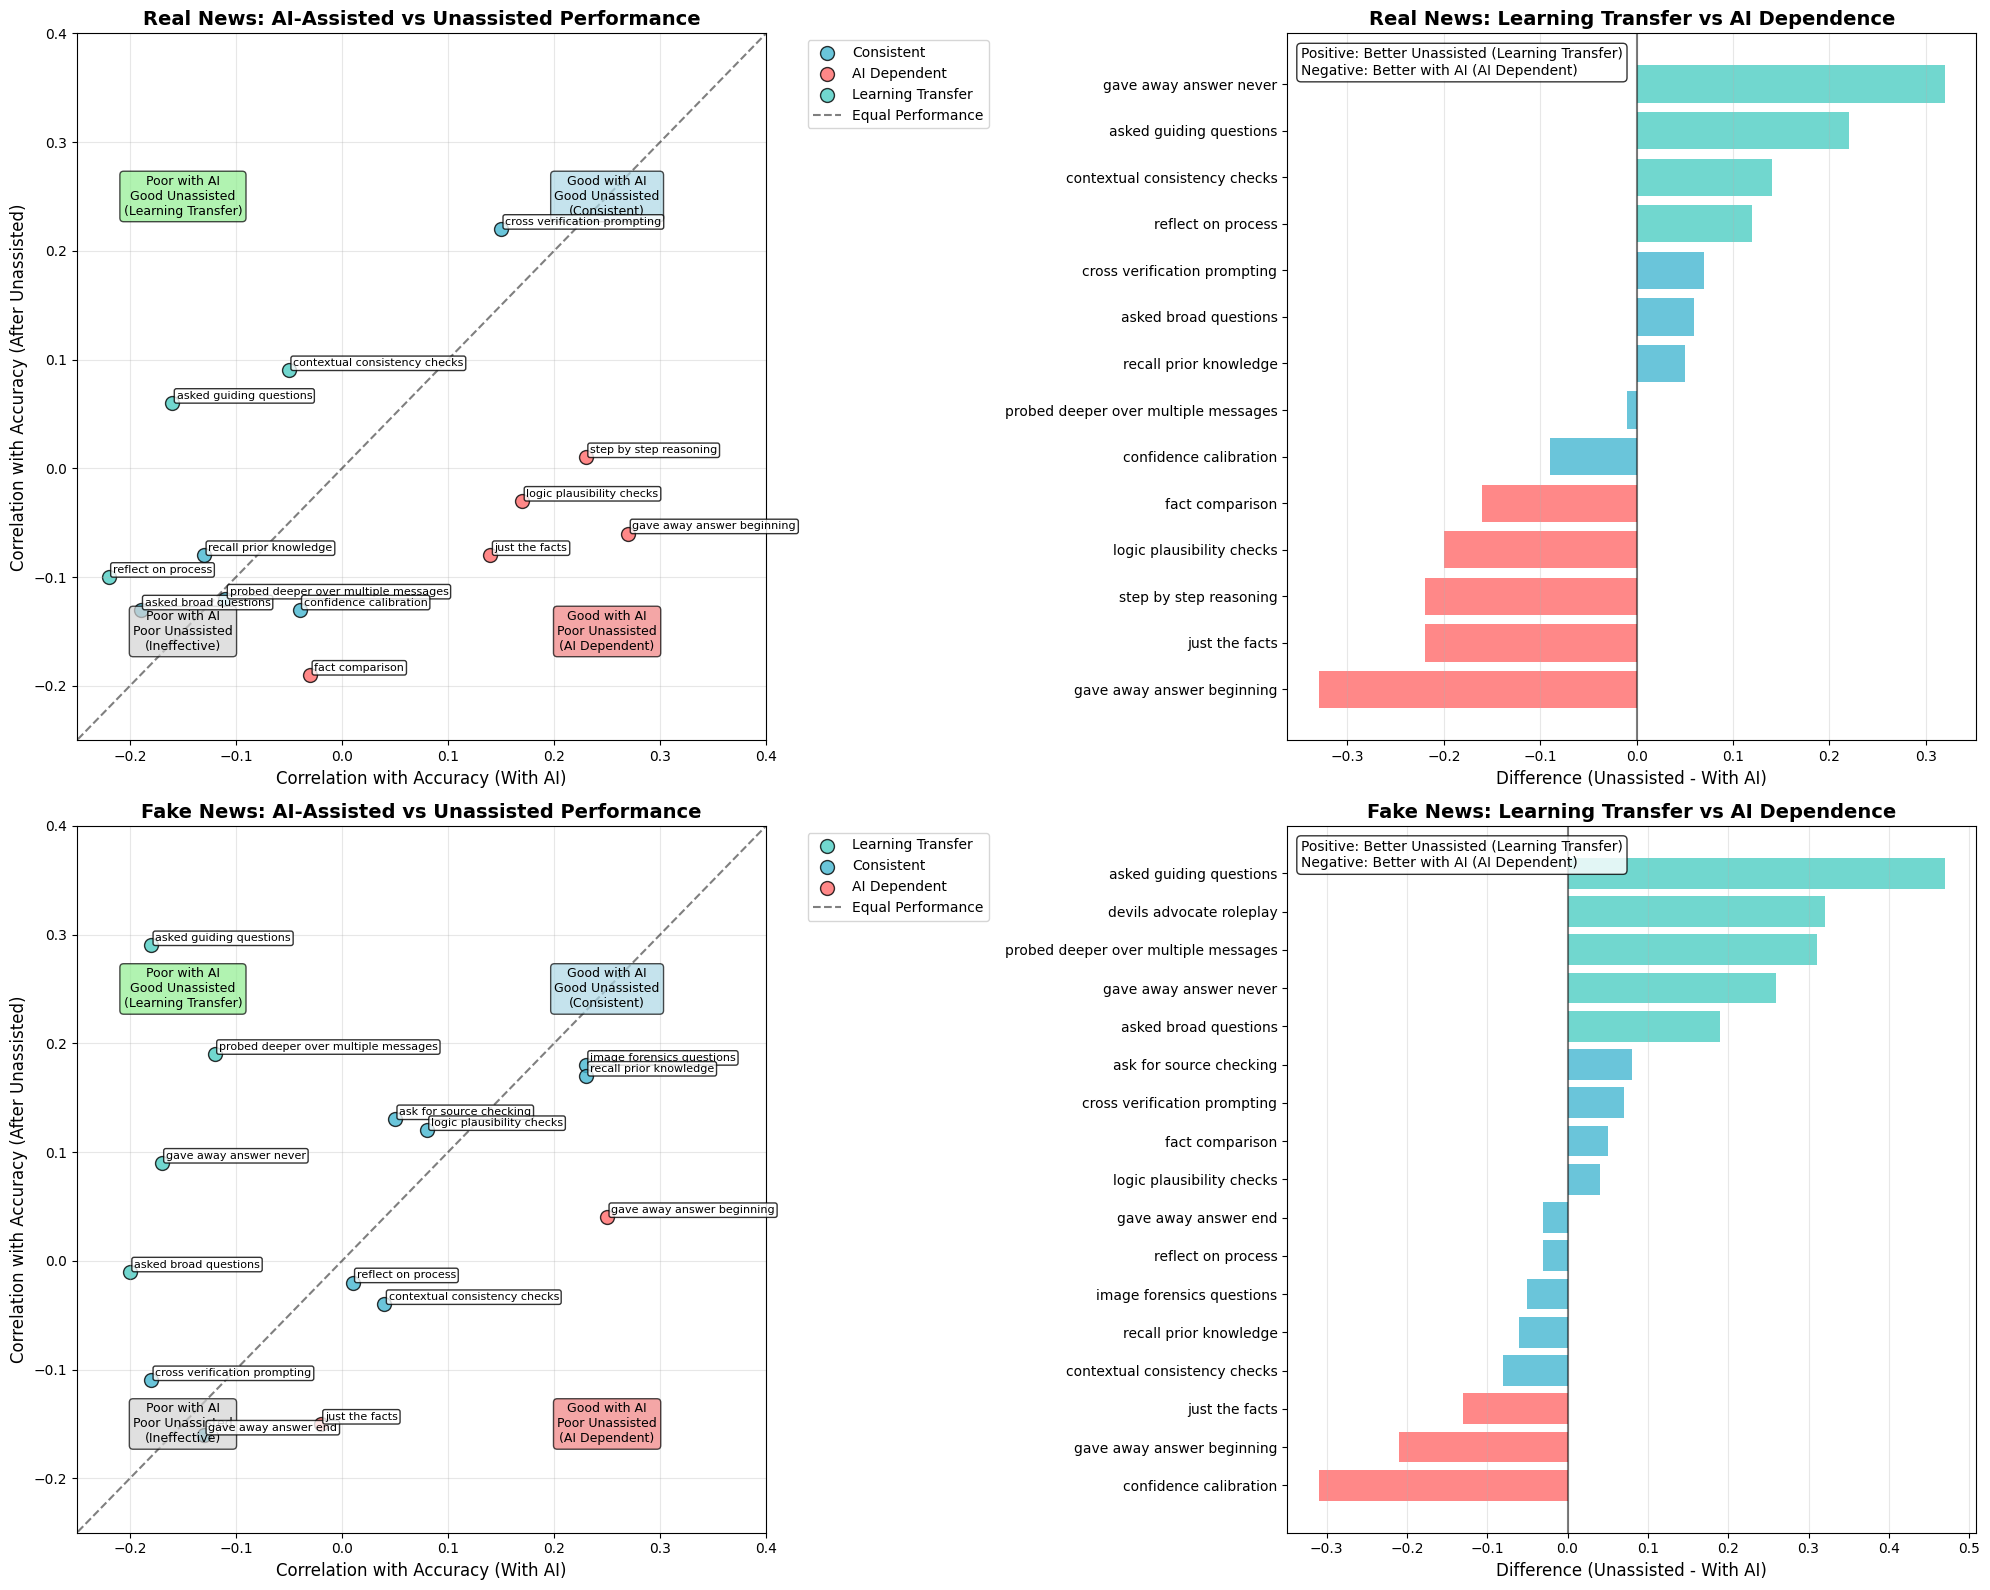


=== DETAILED TRADE-OFF ANALYSIS ===

--- Real News Trade-offs ---

🎓 LEARNING TRANSFER (Better unassisted than with AI - skills transfer):
  gave_away_answer_never: With AI=-0.34, Unassisted=-0.02 (diff=+0.32, std=0.33)
  asked_guiding_questions: With AI=-0.16, Unassisted=0.06 (diff=+0.22, std=0.42)
  contextual_consistency_checks: With AI=-0.05, Unassisted=0.09 (diff=+0.14, std=0.39)
  reflect_on_process: With AI=-0.22, Unassisted=-0.10 (diff=+0.12, std=0.41)

🤖 AI DEPENDENT (Better with AI than unassisted - may create dependence):
  gave_away_answer_beginning: With AI=0.27, Unassisted=-0.06 (diff=-0.33, std=0.38)
  just_the_facts: With AI=0.14, Unassisted=-0.08 (diff=-0.22, std=0.31)
  step_by_step_reasoning: With AI=0.23, Unassisted=0.01 (diff=-0.22, std=0.24)
  logic_plausibility_checks: With AI=0.17, Unassisted=-0.03 (diff=-0.20, std=0.44)
  fact_comparison: With AI=-0.03, Unassisted=-0.19 (diff=-0.16, std=0.50)

⚖️  CONSISTENT STRATEGIES (Similar performance with and without AI)

In [11]:
# Strategy Trade-off Analysis: Performance with AI vs Performance after AI
# Compare "with AI" correlations vs "unassisted (after)" correlations to identify trade-offs

# Check if required variables exist
try:
    test_var = filtered_correlations_with
    print("=== STRATEGY TRADE-OFF ANALYSIS ===")
    print("Comparing performance WITH AI vs performance AFTER AI (unassisted)\n")
except NameError:
    print("ERROR: Please run the previous cell (with reliability filtering) first to define the filtered correlations.")
    print("The variables 'filtered_correlations_with' and 'filtered_correlations_unassisted' need to be defined.")
    # Stop execution here
    raise NameError("Required variables not defined. Run the reliability filtering cell first.")

# Create comparison dataframes for analysis
comparison_data = []

for gt in ['Real', 'Fake']:
    # Get overlapping strategies (those in both filtered sets)
    before_ai_strategies = set(filtered_correlations_before[gt].keys())
    with_ai_strategies = set(filtered_correlations_with[gt].keys())
    unassisted_strategies = set(filtered_correlations_unassisted[gt].keys())
    
    # Only analyze strategies that appear in both analyses (for fair comparison)
    common_strategies = with_ai_strategies.intersection(unassisted_strategies)
    
    for strategy in common_strategies:
        with_ai_corr = filtered_correlations_with[gt][strategy]
        unassisted_corr = filtered_correlations_unassisted[gt][strategy]
        
        comparison_data.append({
            'strategy': strategy,
            'ground_truth': gt,
            'with_ai_correlation': with_ai_corr,
            'unassisted_correlation': unassisted_corr,
            'difference': unassisted_corr - with_ai_corr,  # Positive = better after AI than during AI
            'category': 'Learning Transfer' if unassisted_corr > with_ai_corr + 0.1 else 
                       'AI Dependent' if with_ai_corr > unassisted_corr + 0.1 else 
                       'Consistent'
        })

comparison_df = pd.DataFrame(comparison_data)

# Print summary statistics
print("Strategy Categories by News Type:")
for gt in ['Real', 'Fake']:
    subset = comparison_df[comparison_df['ground_truth'] == gt]
    print(f"\n{gt} News:")
    category_counts = subset['category'].value_counts()
    for category, count in category_counts.items():
        print(f"  {category}: {count} strategies")

# Create the trade-off visualization
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

for gt_idx, gt in enumerate(['Real', 'Fake']):
    subset = comparison_df[comparison_df['ground_truth'] == gt]
    
    # Scatter plot: With AI vs Unassisted correlations
    ax1 = axes[gt_idx, 0]
    
    # Color code by category
    colors = {'Learning Transfer': '#4ECDC4', 'AI Dependent': '#FF6B6B', 'Consistent': '#45B7D1'}
    
    for category in subset['category'].unique():
        cat_data = subset[subset['category'] == category]
        ax1.scatter(cat_data['with_ai_correlation'], cat_data['unassisted_correlation'], 
                   c=colors[category], label=category, alpha=0.8, s=100, edgecolors='black')
    
    # Add diagonal line (where with_ai = unassisted)
    ax1.plot([-0.3, 0.4], [-0.3, 0.4], 'k--', alpha=0.5, label='Equal Performance')
    
    # Add quadrant labels
    ax1.text(0.25, -0.15, 'Good with AI\nPoor Unassisted\n(AI Dependent)', ha='center', va='center', 
             bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7), fontsize=9)
    ax1.text(-0.15, 0.25, 'Poor with AI\nGood Unassisted\n(Learning Transfer)', ha='center', va='center',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7), fontsize=9)
    ax1.text(0.25, 0.25, 'Good with AI\nGood Unassisted\n(Consistent)', ha='center', va='center',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7), fontsize=9)
    ax1.text(-0.15, -0.15, 'Poor with AI\nPoor Unassisted\n(Ineffective)', ha='center', va='center',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.7), fontsize=9)
    
    ax1.set_xlabel('Correlation with Accuracy (With AI)', fontsize=12)
    ax1.set_ylabel('Correlation with Accuracy (After Unassisted)', fontsize=12)
    ax1.set_title(f'{gt} News: AI-Assisted vs Unassisted Performance', fontsize=14, fontweight='bold')
    ax1.set_xlim(-0.25, 0.4)
    ax1.set_ylim(-0.25, 0.4)
    ax1.grid(True, alpha=0.3)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add strategy labels for all strategies
    for _, row in subset.iterrows():
        ax1.annotate(row['strategy'].replace('_', ' '), 
                    (row['with_ai_correlation'], row['unassisted_correlation']),
                    xytext=(3, 3), textcoords='offset points', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
    
    # Bar plot: Difference (Unassisted - With AI)
    ax2 = axes[gt_idx, 1]
    
    # Sort by difference
    subset_sorted = subset.sort_values('difference', ascending=True)
    colors_list = [colors[cat] for cat in subset_sorted['category']]
    
    bars = ax2.barh(range(len(subset_sorted)), subset_sorted['difference'], 
                    color=colors_list, alpha=0.8)
    
    ax2.set_yticks(range(len(subset_sorted)))
    ax2.set_yticklabels([s.replace('_', ' ') for s in subset_sorted['strategy']], fontsize=10)
    ax2.set_xlabel('Difference (Unassisted - With AI)', fontsize=12)
    ax2.set_title(f'{gt} News: Learning Transfer vs AI Dependence', fontsize=14, fontweight='bold')
    ax2.axvline(x=0, color='black', linestyle='-', alpha=0.5)
    ax2.grid(axis='x', alpha=0.3)
    
    # Add interpretation text
    ax2.text(0.02, 0.98, 'Positive: Better Unassisted (Learning Transfer)\nNegative: Better with AI (AI Dependent)', 
             transform=ax2.transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Detailed analysis of trade-offs
print("\n=== DETAILED TRADE-OFF ANALYSIS ===")

for gt in ['Real', 'Fake']:
    subset = comparison_df[comparison_df['ground_truth'] == gt]
    print(f"\n--- {gt} News Trade-offs ---")
    
    # Learning Transfer strategies (better unassisted than with AI)
    learning_transfer = subset[subset['category'] == 'Learning Transfer'].sort_values('difference', ascending=False)
    if not learning_transfer.empty:
        print("\n🎓 LEARNING TRANSFER (Better unassisted than with AI - skills transfer):")
        for _, row in learning_transfer.iterrows():
            # Calculate standard deviations for this strategy
            strategy_data = data[data['ground_truth'] == gt][row['strategy']].dropna()
            strategy_std = pd.to_numeric(strategy_data, errors='coerce').std()
            print(f"  {row['strategy']}: With AI={row['with_ai_correlation']:.2f}, Unassisted={row['unassisted_correlation']:.2f} (diff={row['difference']:+.2f}, std={strategy_std:.2f})")
    
    # AI Dependent strategies (better with AI than unassisted)
    ai_dependent = subset[subset['category'] == 'AI Dependent'].sort_values('difference', ascending=True)
    if not ai_dependent.empty:
        print("\n🤖 AI DEPENDENT (Better with AI than unassisted - may create dependence):")
        for _, row in ai_dependent.iterrows():
            # Calculate standard deviations for this strategy
            strategy_data = data[data['ground_truth'] == gt][row['strategy']].dropna()
            strategy_std = pd.to_numeric(strategy_data, errors='coerce').std()
            print(f"  {row['strategy']}: With AI={row['with_ai_correlation']:.2f}, Unassisted={row['unassisted_correlation']:.2f} (diff={row['difference']:+.2f}, std={strategy_std:.2f})")
    
    # Consistent strategies
    consistent = subset[subset['category'] == 'Consistent'].sort_values('with_ai_correlation', ascending=False)
    if not consistent.empty:
        print("\n⚖️  CONSISTENT STRATEGIES (Similar performance with and without AI):")
        for _, row in consistent.iterrows():
            # Calculate standard deviations for this strategy
            strategy_data = data[data['ground_truth'] == gt][row['strategy']].dropna()
            strategy_std = pd.to_numeric(strategy_data, errors='coerce').std()
            print(f"  {row['strategy']}: With AI={row['with_ai_correlation']:.2f}, Unassisted={row['unassisted_correlation']:.2f} (diff={row['difference']:+.2f}, std={strategy_std:.2f})")

# Summary insights
print("\n=== KEY INSIGHTS ===")
print("1. LEARNING TRANSFER: Strategies that work better unassisted than with AI - suggest genuine skill development")
print("2. AI DEPENDENT: Strategies that work better with AI than unassisted - may create over-reliance")
print("3. CONSISTENT: Strategies that work similarly with and without AI - balanced approach")

# Calculate overall patterns with standard deviations
all_data = comparison_df.groupby('category').agg({
    'with_ai_correlation': ['mean', 'std'],
    'unassisted_correlation': ['mean', 'std'],
    'difference': ['mean', 'std']
}).round(2)

print(f"\nOverall Patterns (averaged across Real and Fake news):")
for category in all_data.index:
    with_ai_mean = all_data.loc[category, ('with_ai_correlation', 'mean')]
    with_ai_std = all_data.loc[category, ('with_ai_correlation', 'std')]
    unassisted_mean = all_data.loc[category, ('unassisted_correlation', 'mean')]
    unassisted_std = all_data.loc[category, ('unassisted_correlation', 'std')]
    diff_mean = all_data.loc[category, ('difference', 'mean')]
    diff_std = all_data.loc[category, ('difference', 'std')]
    
    print(f"  {category}: Avg With AI={with_ai_mean}±{with_ai_std}, Avg Unassisted={unassisted_mean}±{unassisted_std}, Avg Difference={diff_mean:+.2f}±{diff_std:.2f}")

print(f"\nDesign Recommendations:")
print(f"• For IMMEDIATE accuracy: Focus on AI Dependent strategies")
print(f"• For SKILL TRANSFER: Focus on Learning Transfer strategies") 
print(f"• For BALANCED approach: Focus on Consistent strategies")